In [2]:
# Only run this cell if the required packages are not installed
!pip install pandas matplotlib scikit-learn numpy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [4]:
filesDir = "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/"
model = "19to1"
samples = ["bkg", "Ato4l", "hToTauTau", "hToTauNu", "LQ"]
quantizations = ["float32", "32bit", "28bit", "24bit", "20bit", "18bit", "16bit", "14bit", "13bit", "12bit"]

In [5]:
quantization_colors = {
    "float32": "#ff7f0e", # orange
    "32bit": "#2ca02c", # green
    "28bit": "#d62728", # red
    "24bit":"#1f77b4", # blue
    "20bit":"#9467bd", # purple
    "18bit":"#3bea23", # parrot green
    "16bit":"#8c564b", # brown
    "14bit":"#e377c2", # pink
    "13bit":"#517bec", # light blue
    "12bit":"#ddca1c", # yellow
    "8bit":"#7f7f7f" # gray
}

In [6]:
sample_colors = {
    "bkg": "#1f77b4", # blue
    "Ato4l": "#ff7f0e", # orange
    "hToTauTau": "#2ca02c", # green
    "hToTauNu": "#d62728", # red
    "LQ": "#9467bd", # purple
}

In [7]:
legend_names = {
    "float32": "float32",
    "32bit": "32-bit",
    "28bit": "28-bit",
    "24bit": "24-bit",
    "20bit": "20-bit",
    "18bit": "18-bit",
    "16bit": "16-bit",
    "14bit": "14-bit",
    "13bit": "13-bit",
    "12bit": "12-bit",
    "8bit": "8-bit",
    "bkg": "Background",
    "Ato4l": "$A\u21924l$",
    "hToTauTau": "$h^0\u2192\u03C4\u03C4$",
    "hToTauNu": "$h^\u00b1\u2192\u03C4\u03BD$",
    "LQ": "$LQ\u2192b\u03C4$",
}

In [8]:
# Where to save the comparison plots
output_plot_dir = "../output/QuantizationComparison/"
os.makedirs(output_plot_dir, exist_ok=True)

In [9]:
def load_norm_data(file_path):
    """Load normalization data from a whitespace-delimited file."""
    # Only keep the first column (norm values) and ignore the rest
    return pd.read_csv(file_path, sep='\s+', comment="#", header=None, usecols=[0], names=['norm'])

In [10]:
norms = {}

for quant in quantizations:
    bit_dir = filesDir + "/" + model + "/" + quant
    norms[quant] = {}

    for sample in samples:
        file_path = os.path.join(bit_dir, sample + ".dat")
        df = load_norm_data(file_path)
        norms[quant][sample] = df['norm'].to_numpy()


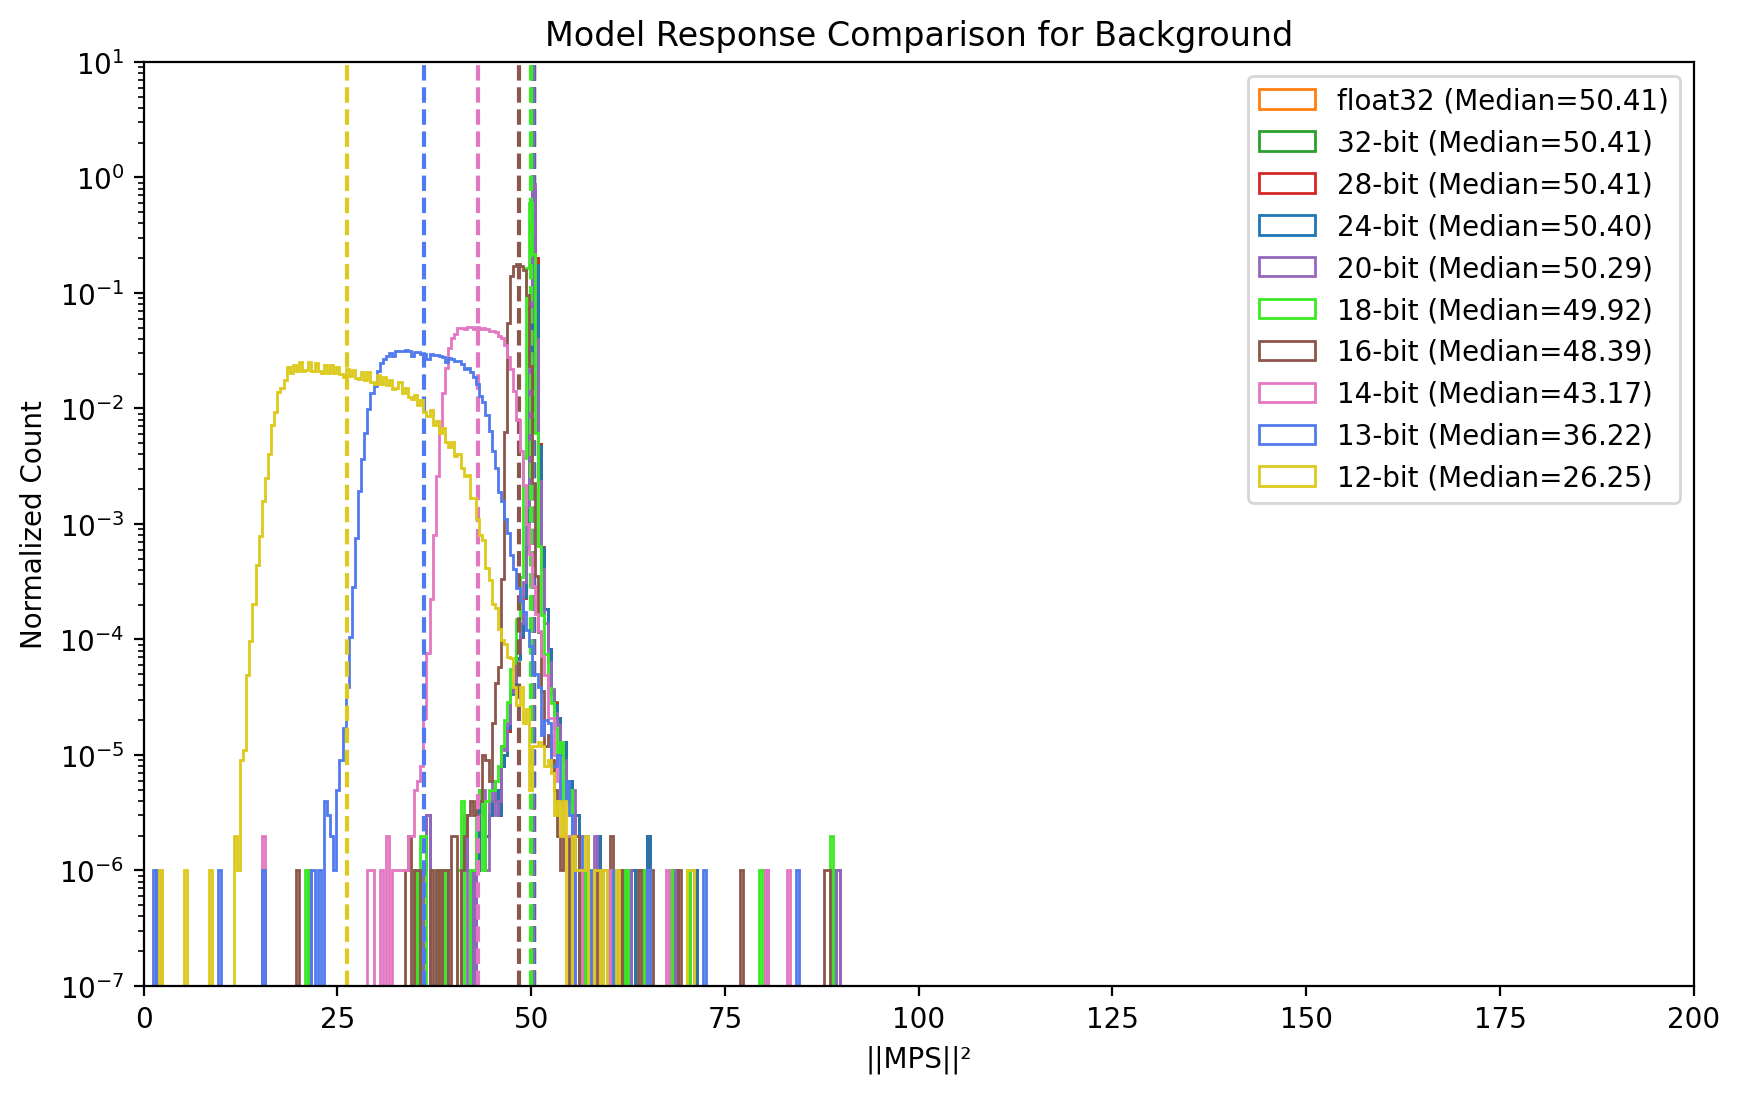

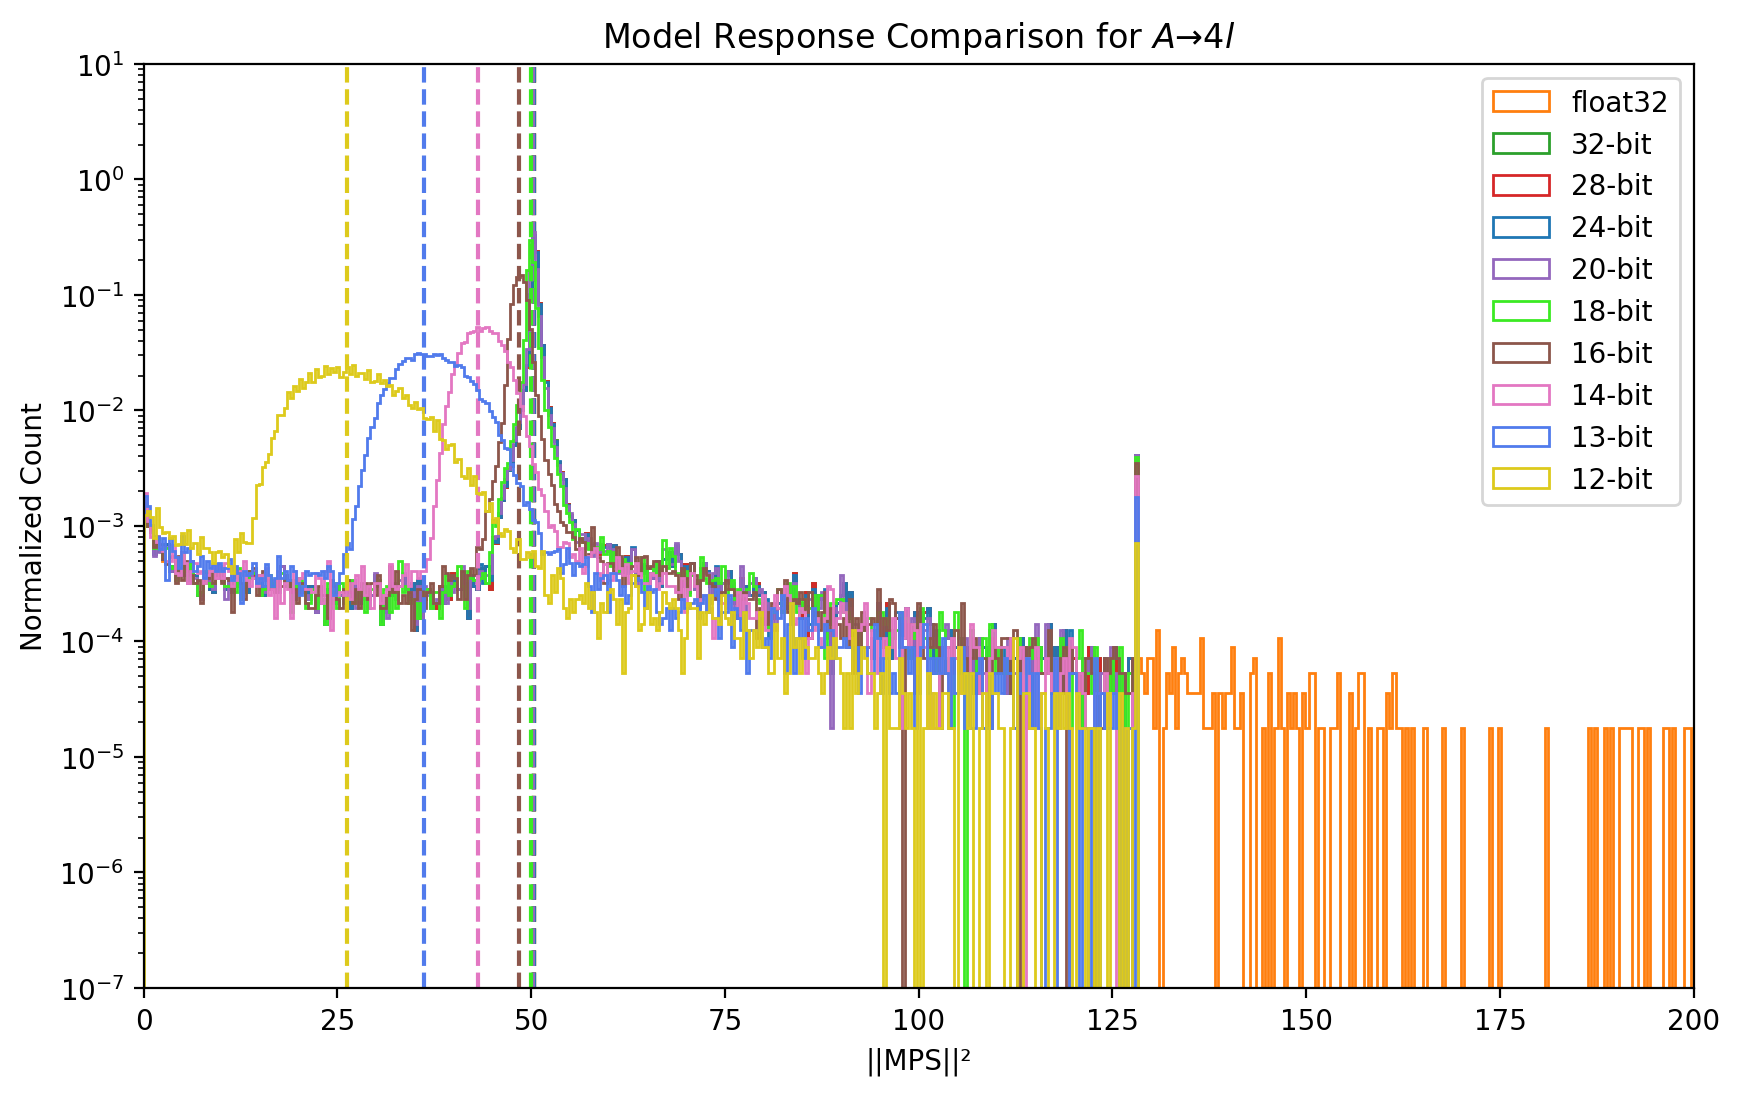

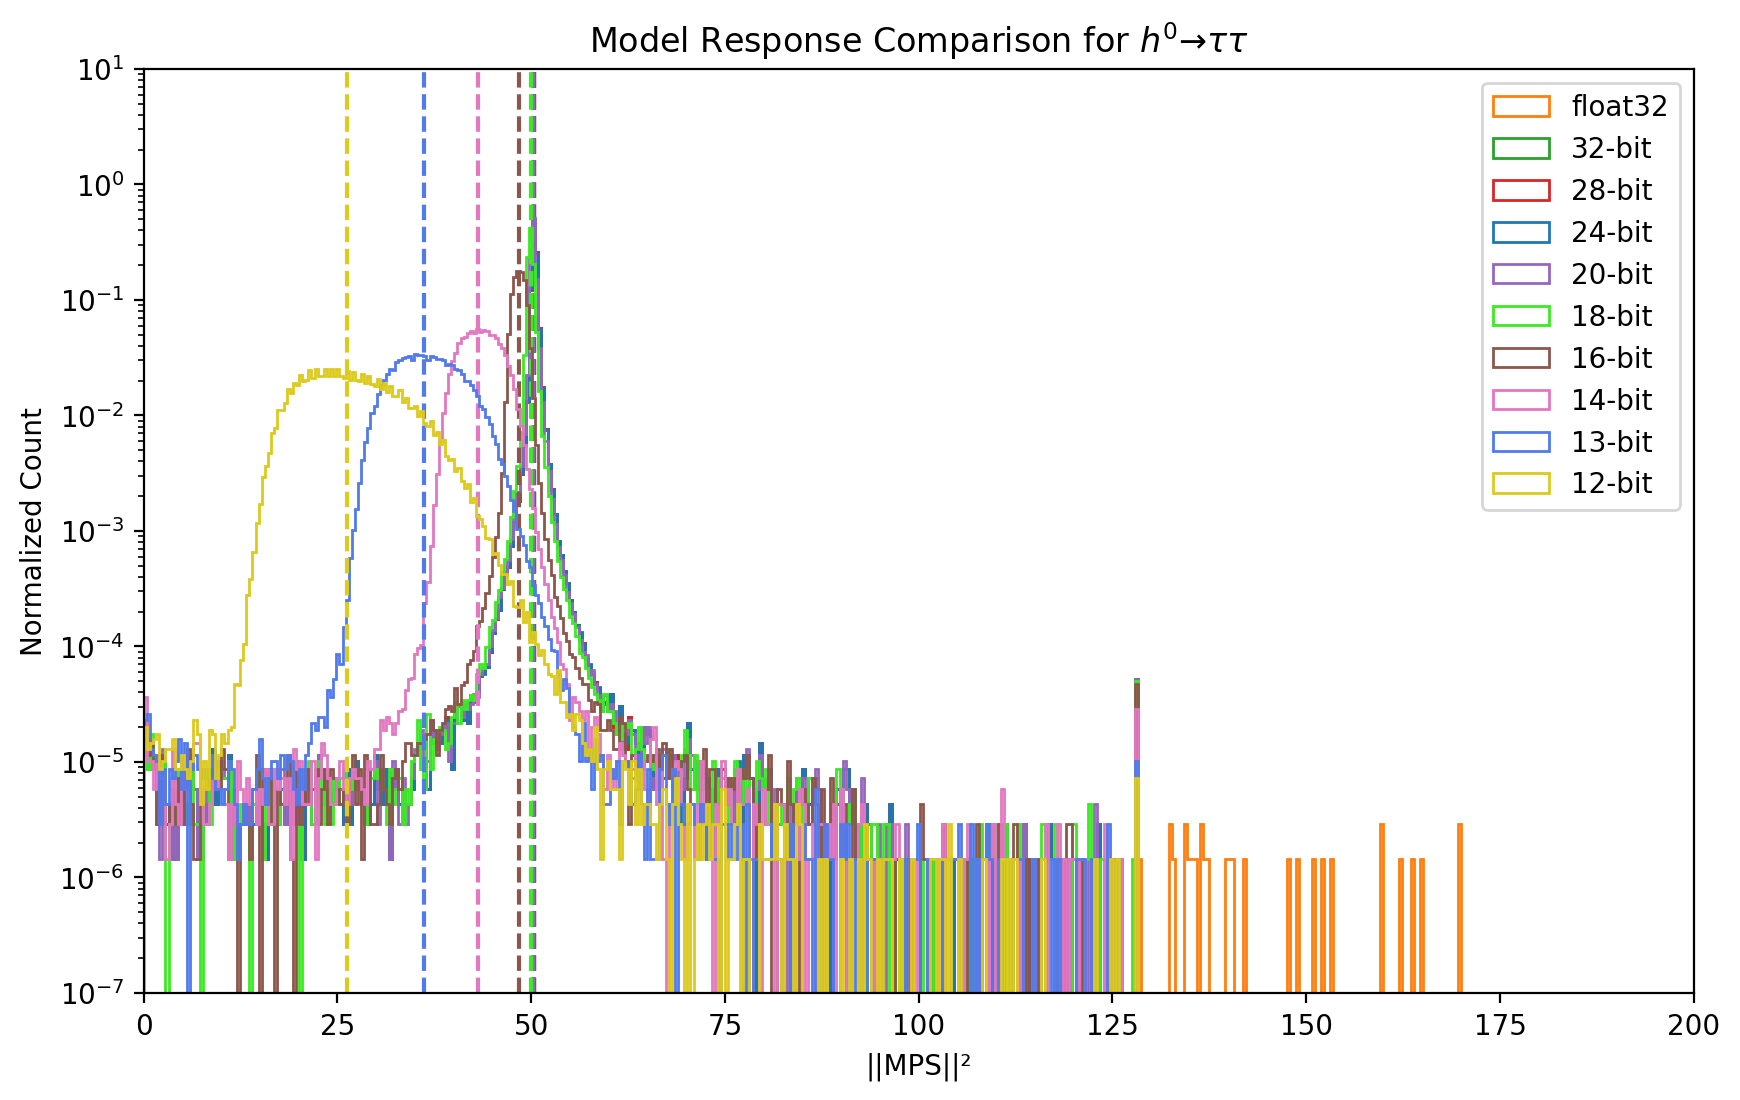

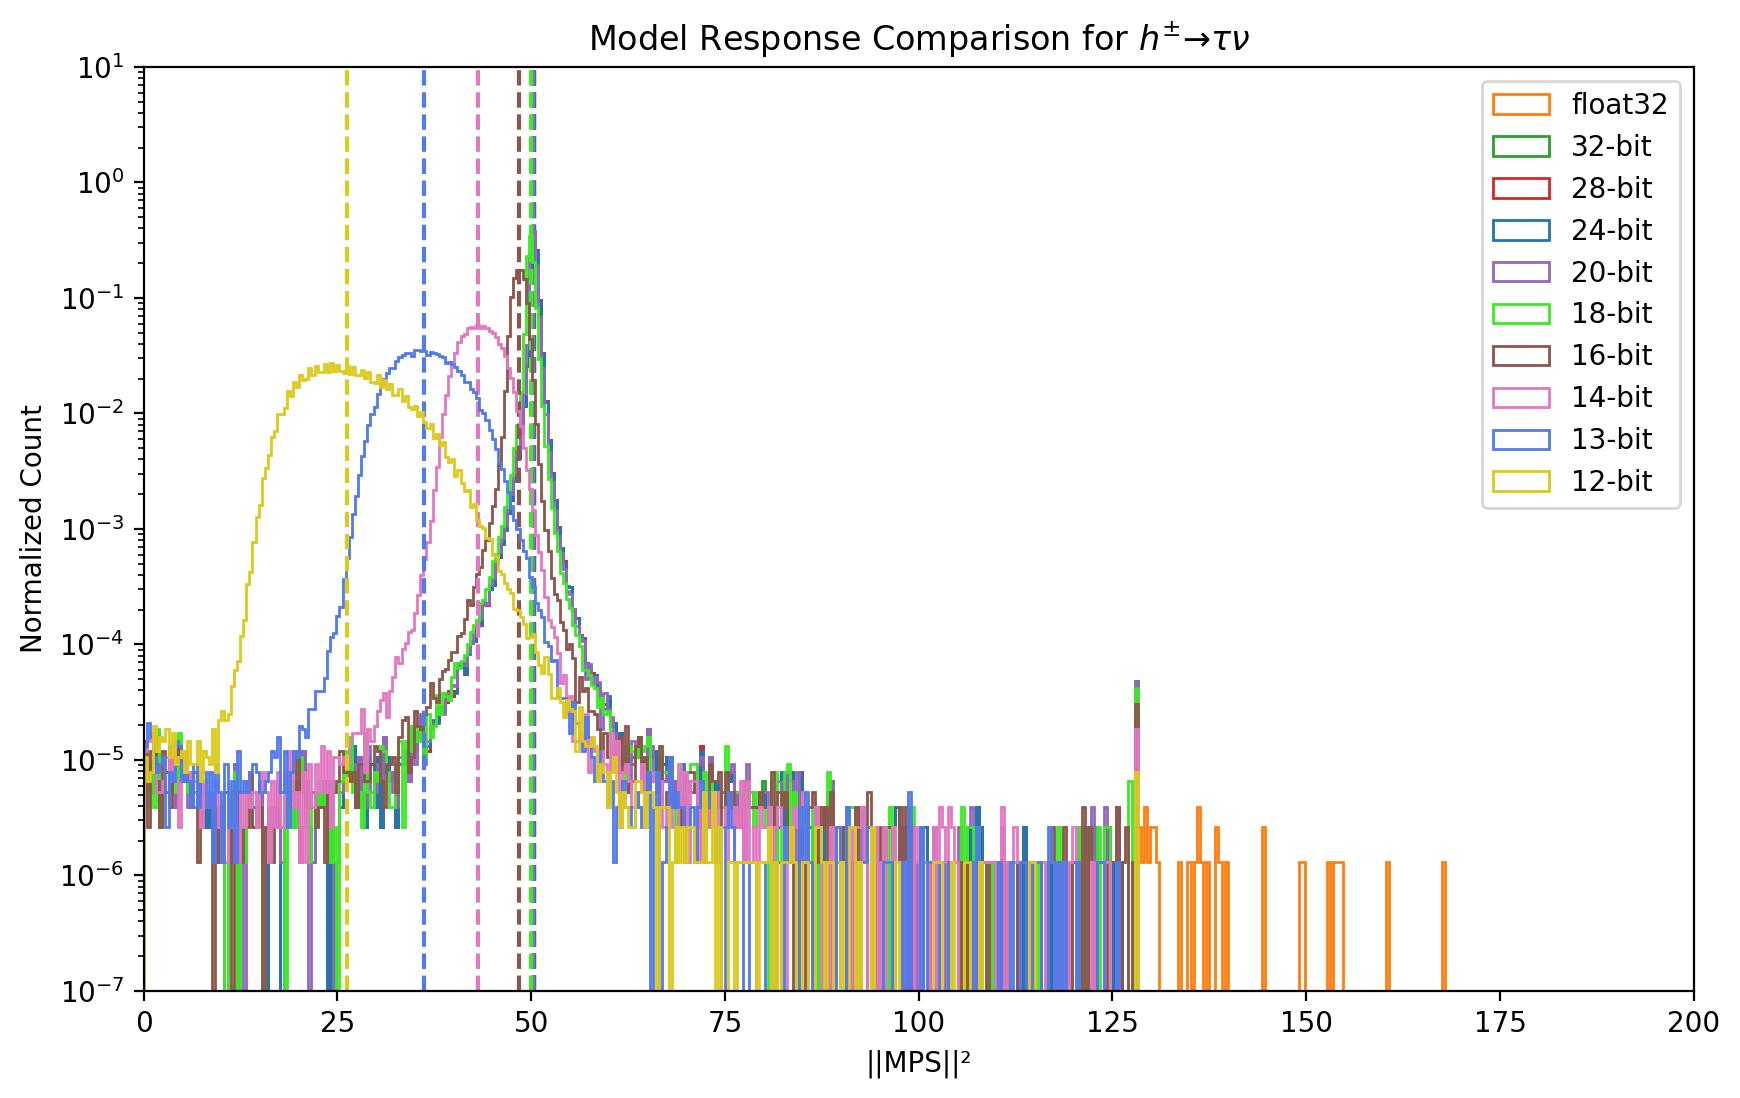

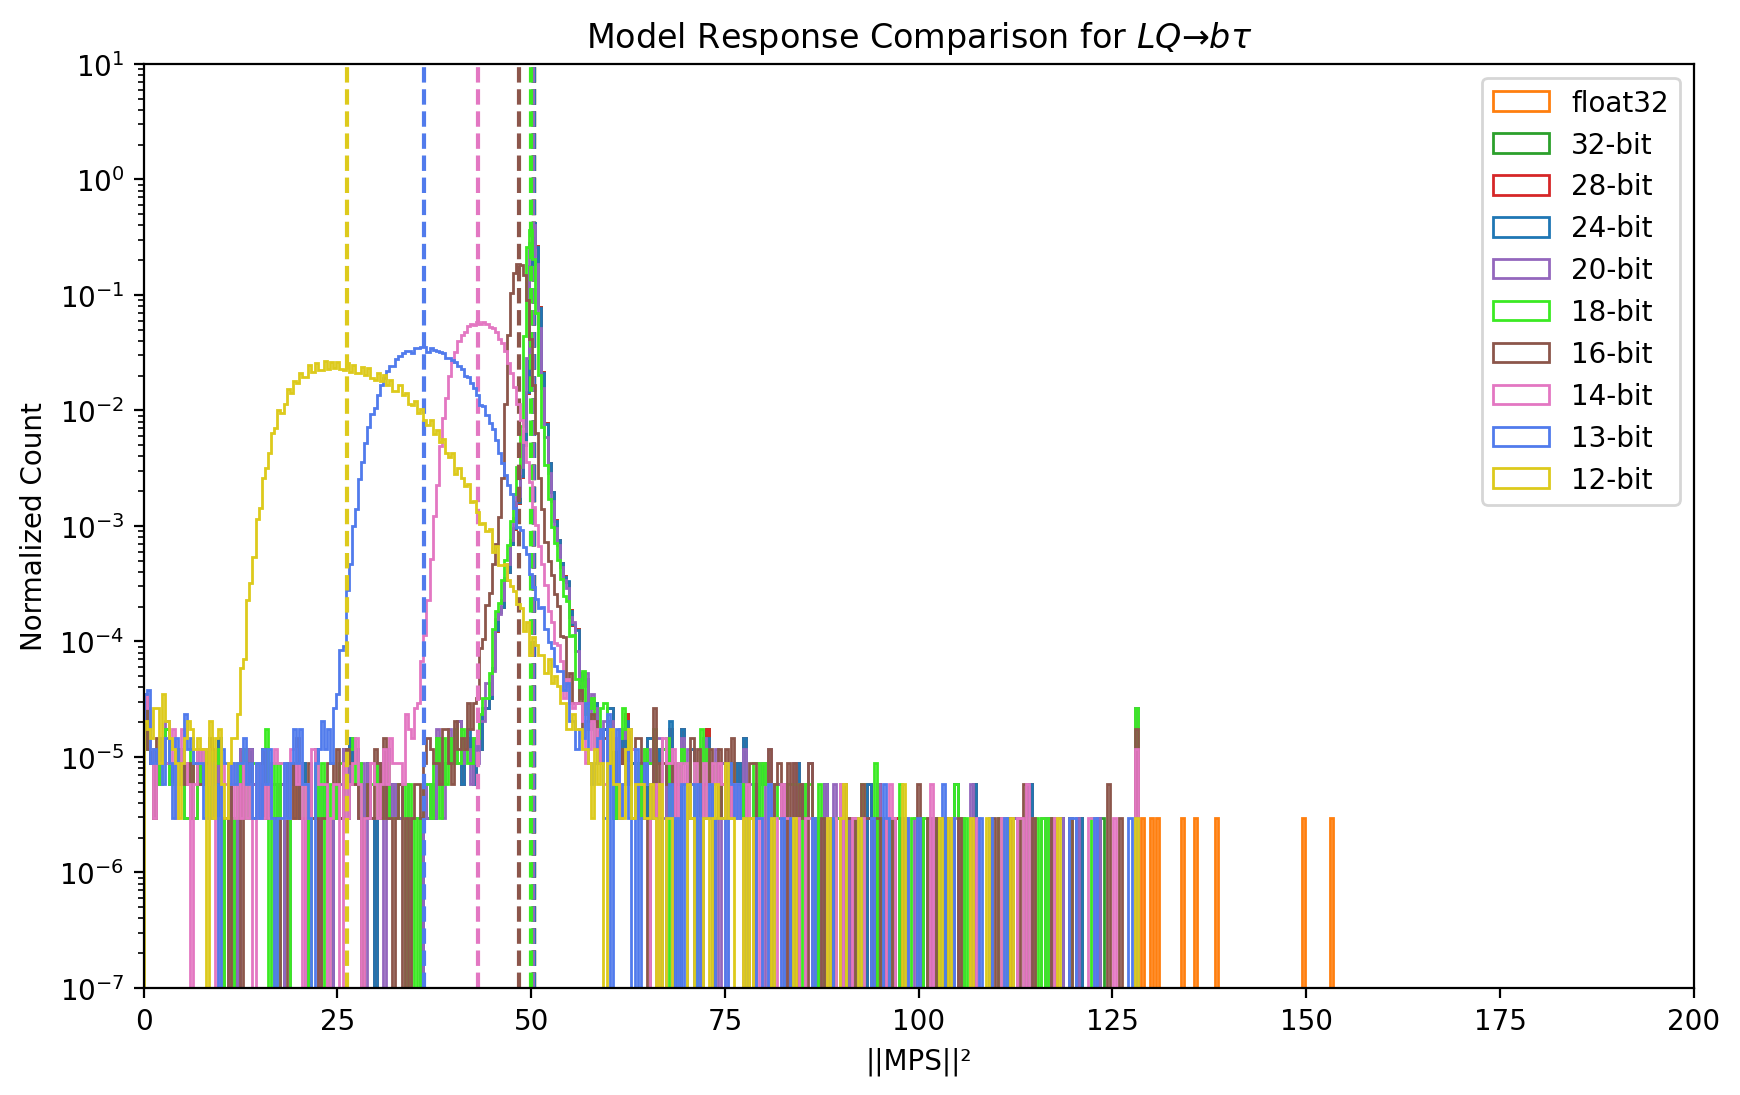

In [11]:
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, 500)
median = {}
for quant in quantizations:
    median[quant] = np.median(norms[quant]["bkg"])
for sample in samples:
    plt.figure(figsize=(10, 6), dpi=200)
    for quant in quantizations:
        label = legend_names[quant]
        if sample == "bkg":
            label += f" (Median={median[quant]:.2f})"
        plt.hist(norms[quant][sample], weights=np.array([1.]*len(norms[quant][sample]))/len(norms[quant][sample]), bins=bins, histtype='step', color=quantization_colors[quant], label=label)
        plt.axvline(median[quant], color=quantization_colors[quant], linestyle='--')
    plt.xlabel("||MPS||\u00b2")
    plt.yscale("log")
    plt.ylim(1e-7, 10)
    plt.xlim(xmin, xmax)
    plt.ylabel("Normalized Count")
    plt.title(f"Model Response Comparison for {legend_names[sample]}")
    plt.legend()
    plt.show()

In [12]:
def get_anomaly_scores(norm, target):
    return np.abs(norm - target)

In [13]:
anomaly_scores = {}
for quant in quantizations:
    anomaly_scores[quant] = {}
    for sample in samples:
        anomaly_scores[quant][sample] = get_anomaly_scores(norms[quant][sample], median[quant])

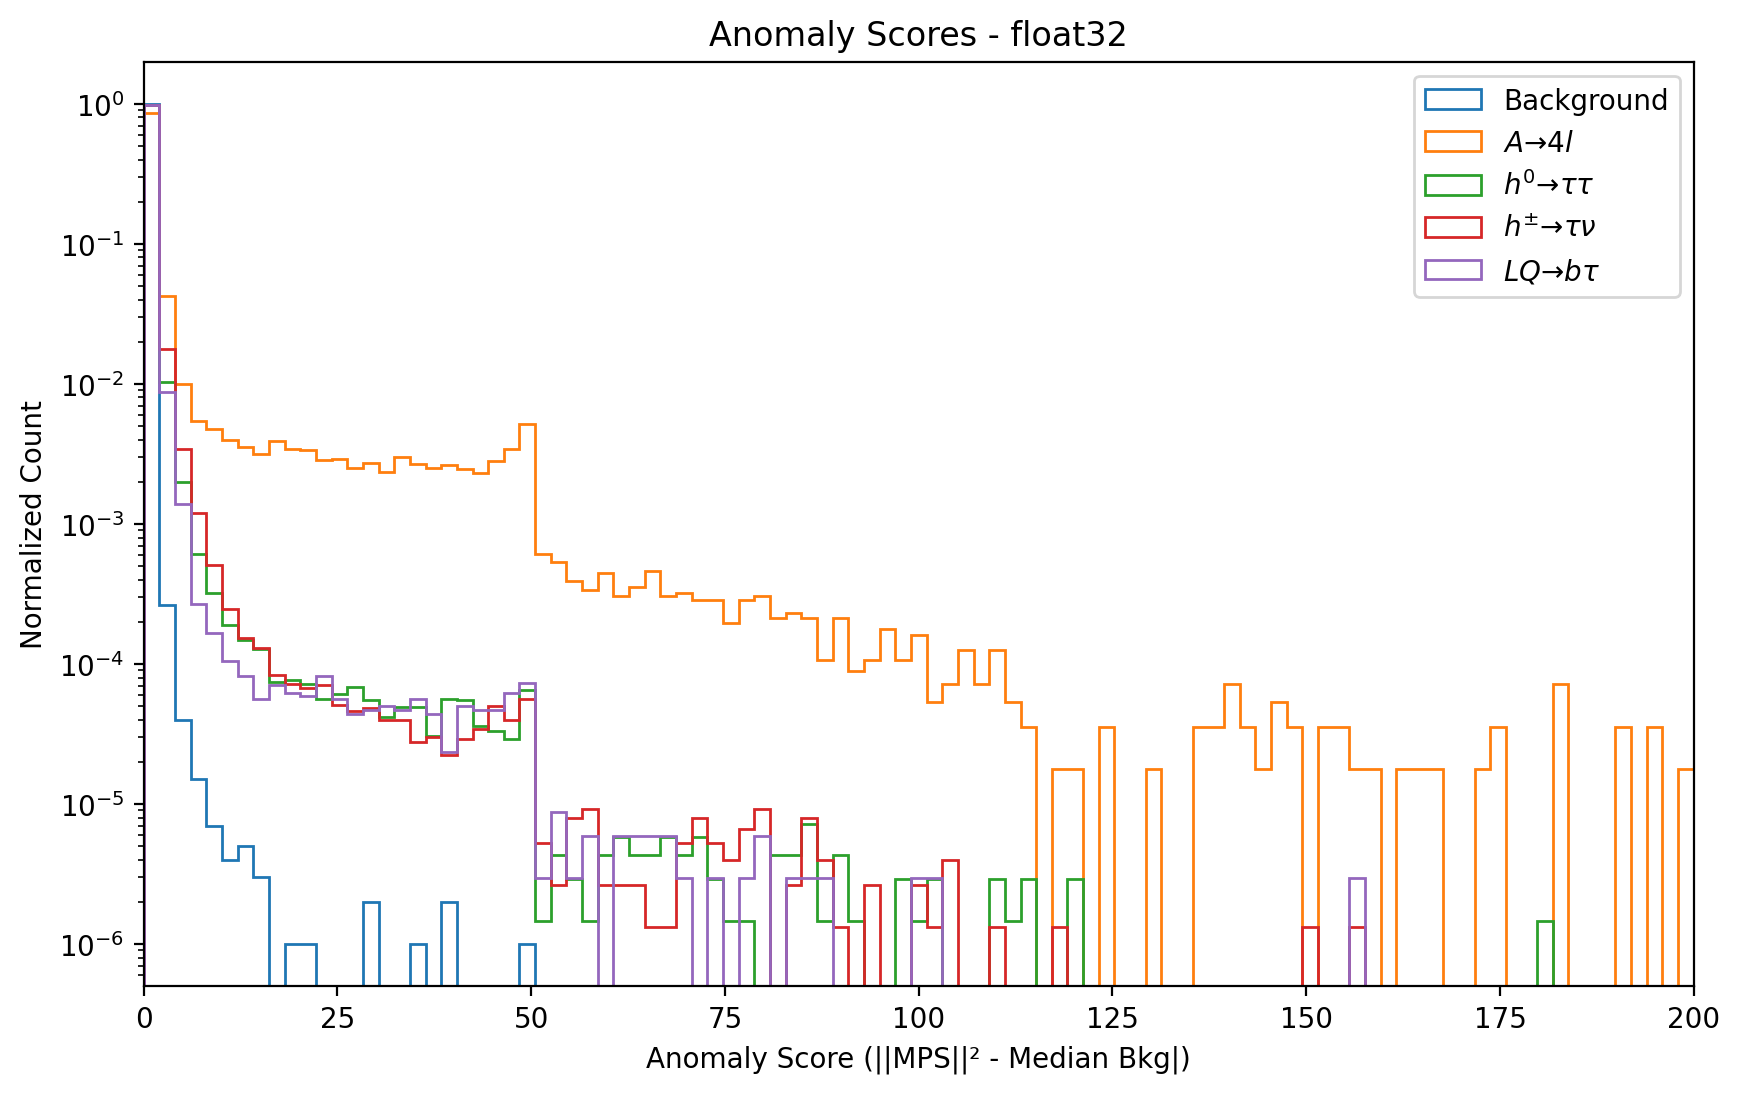

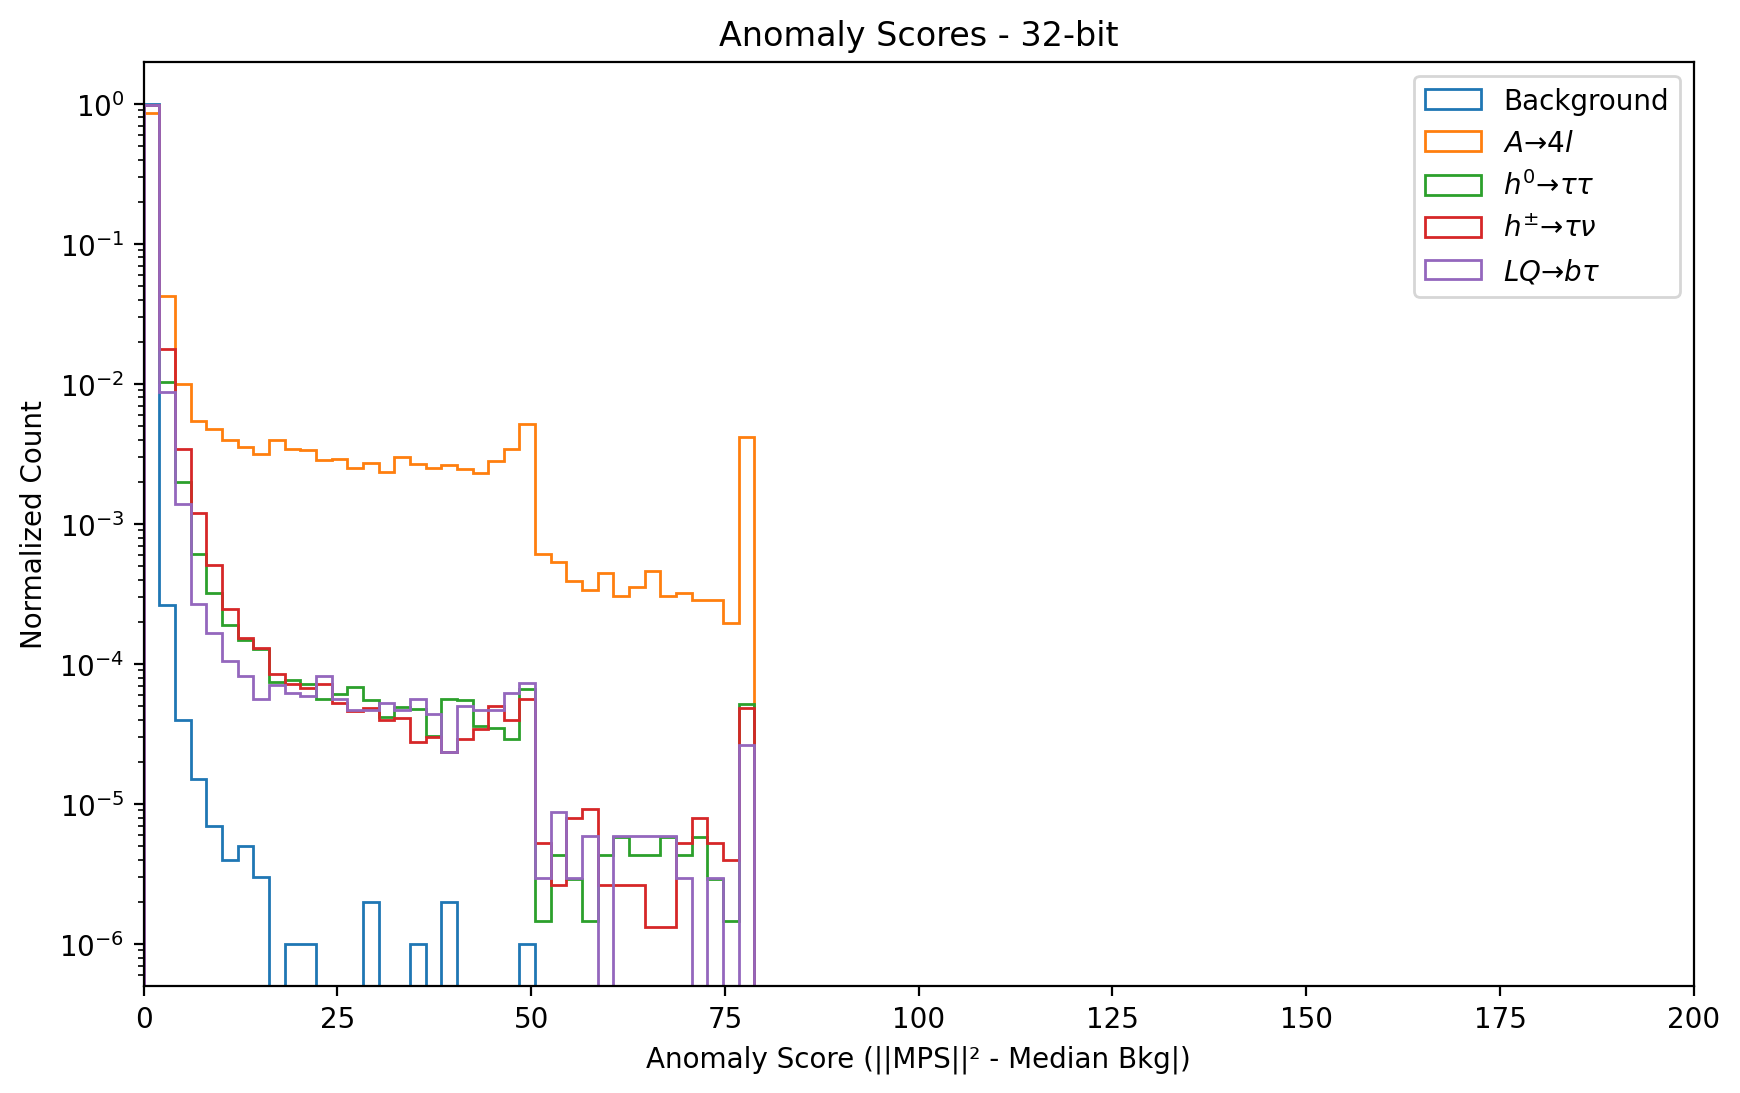

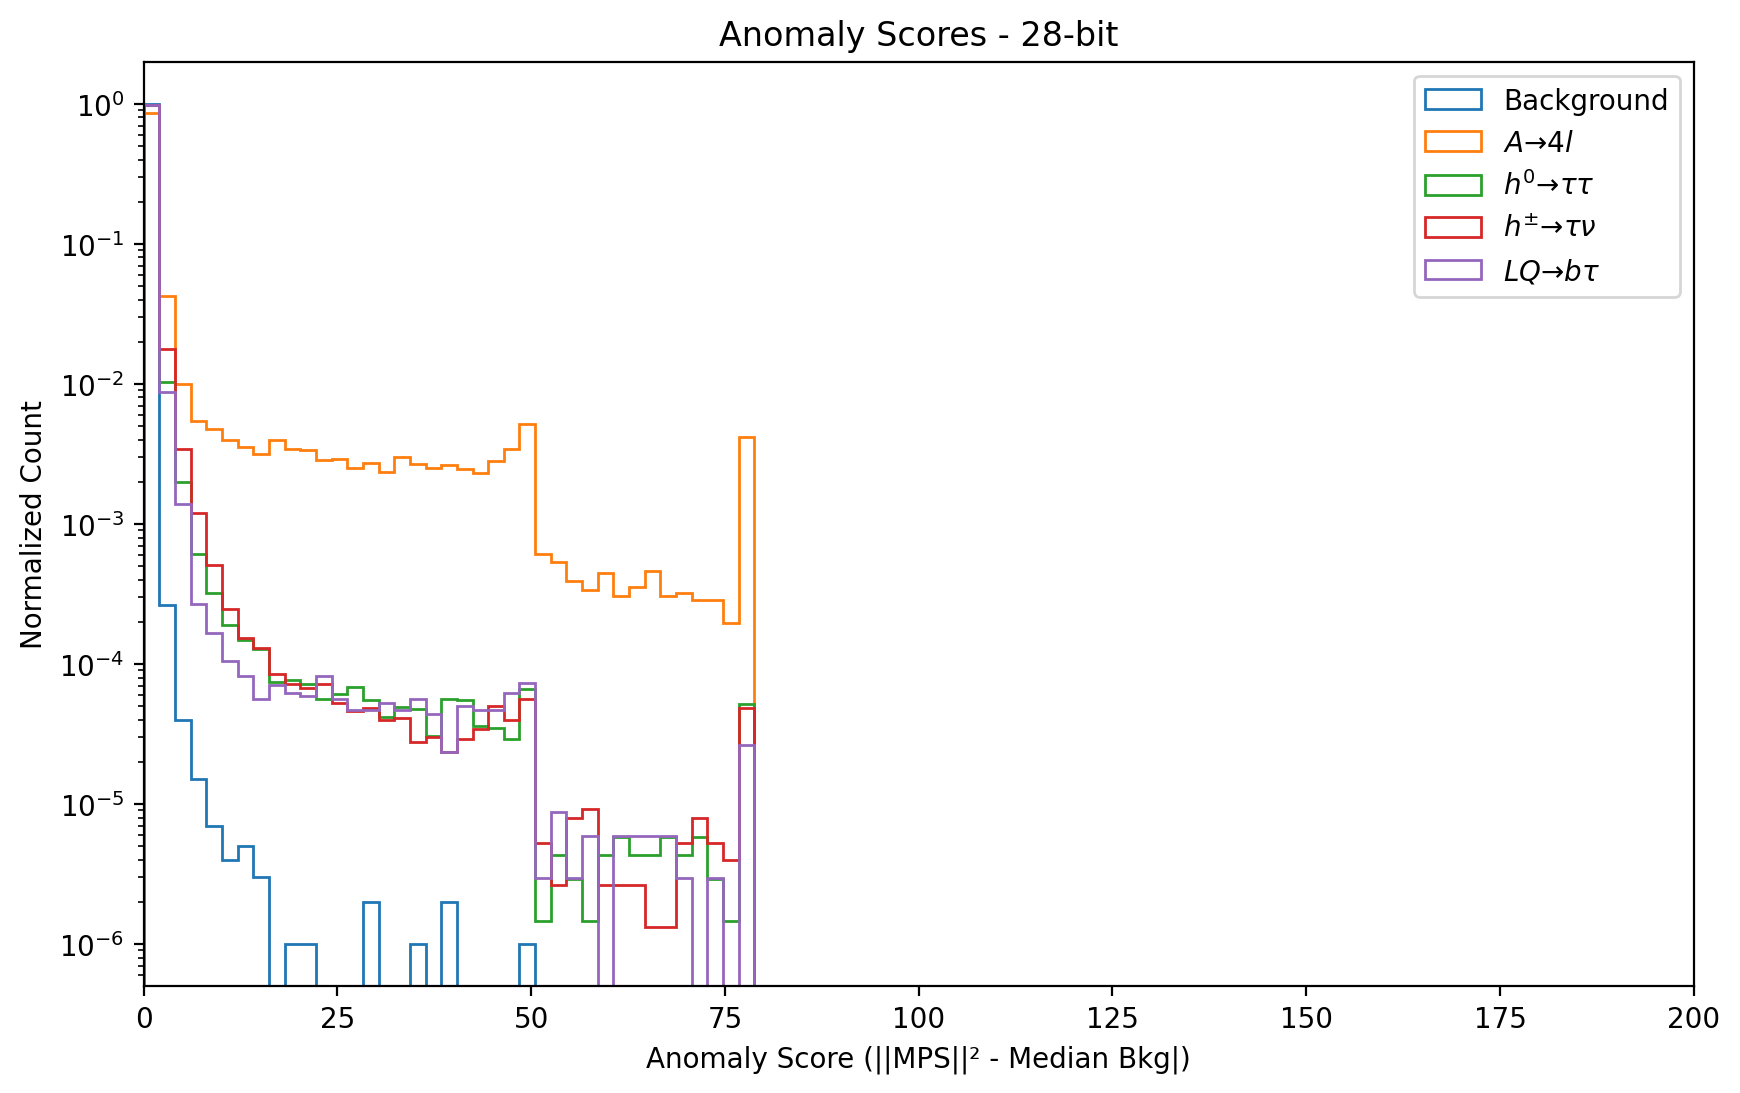

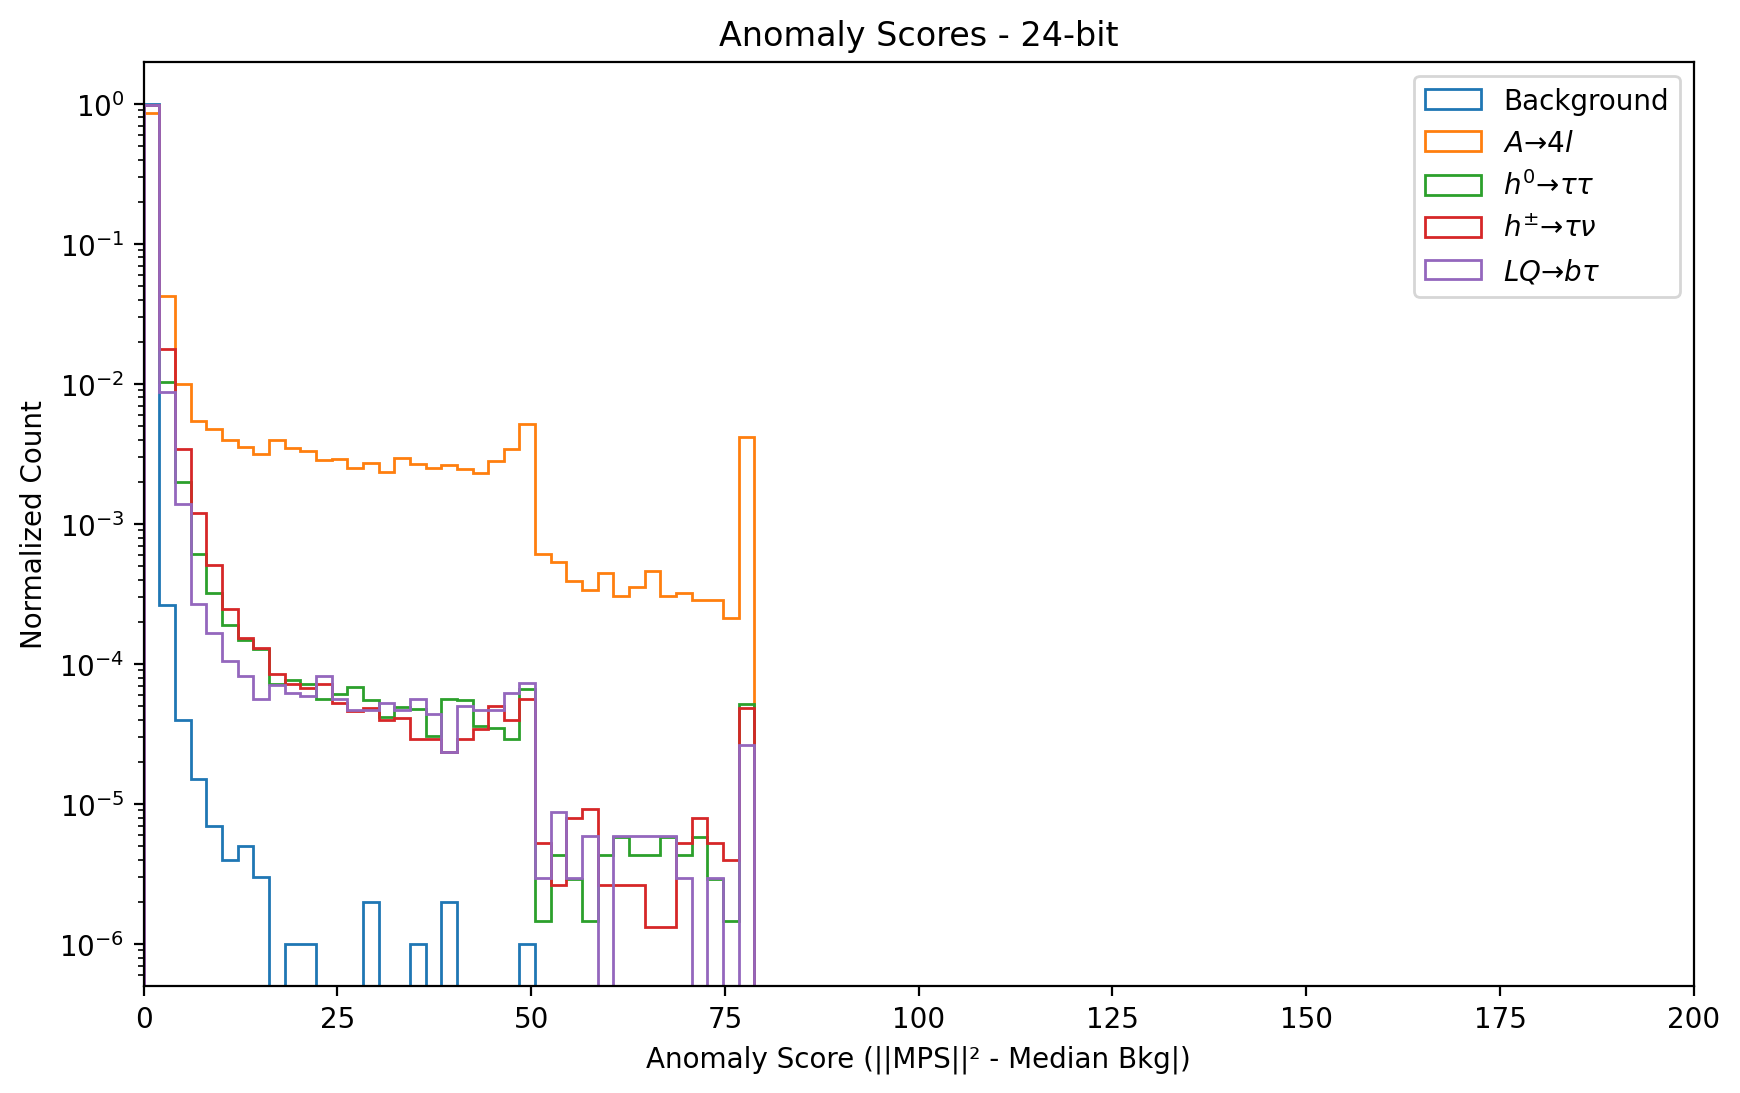

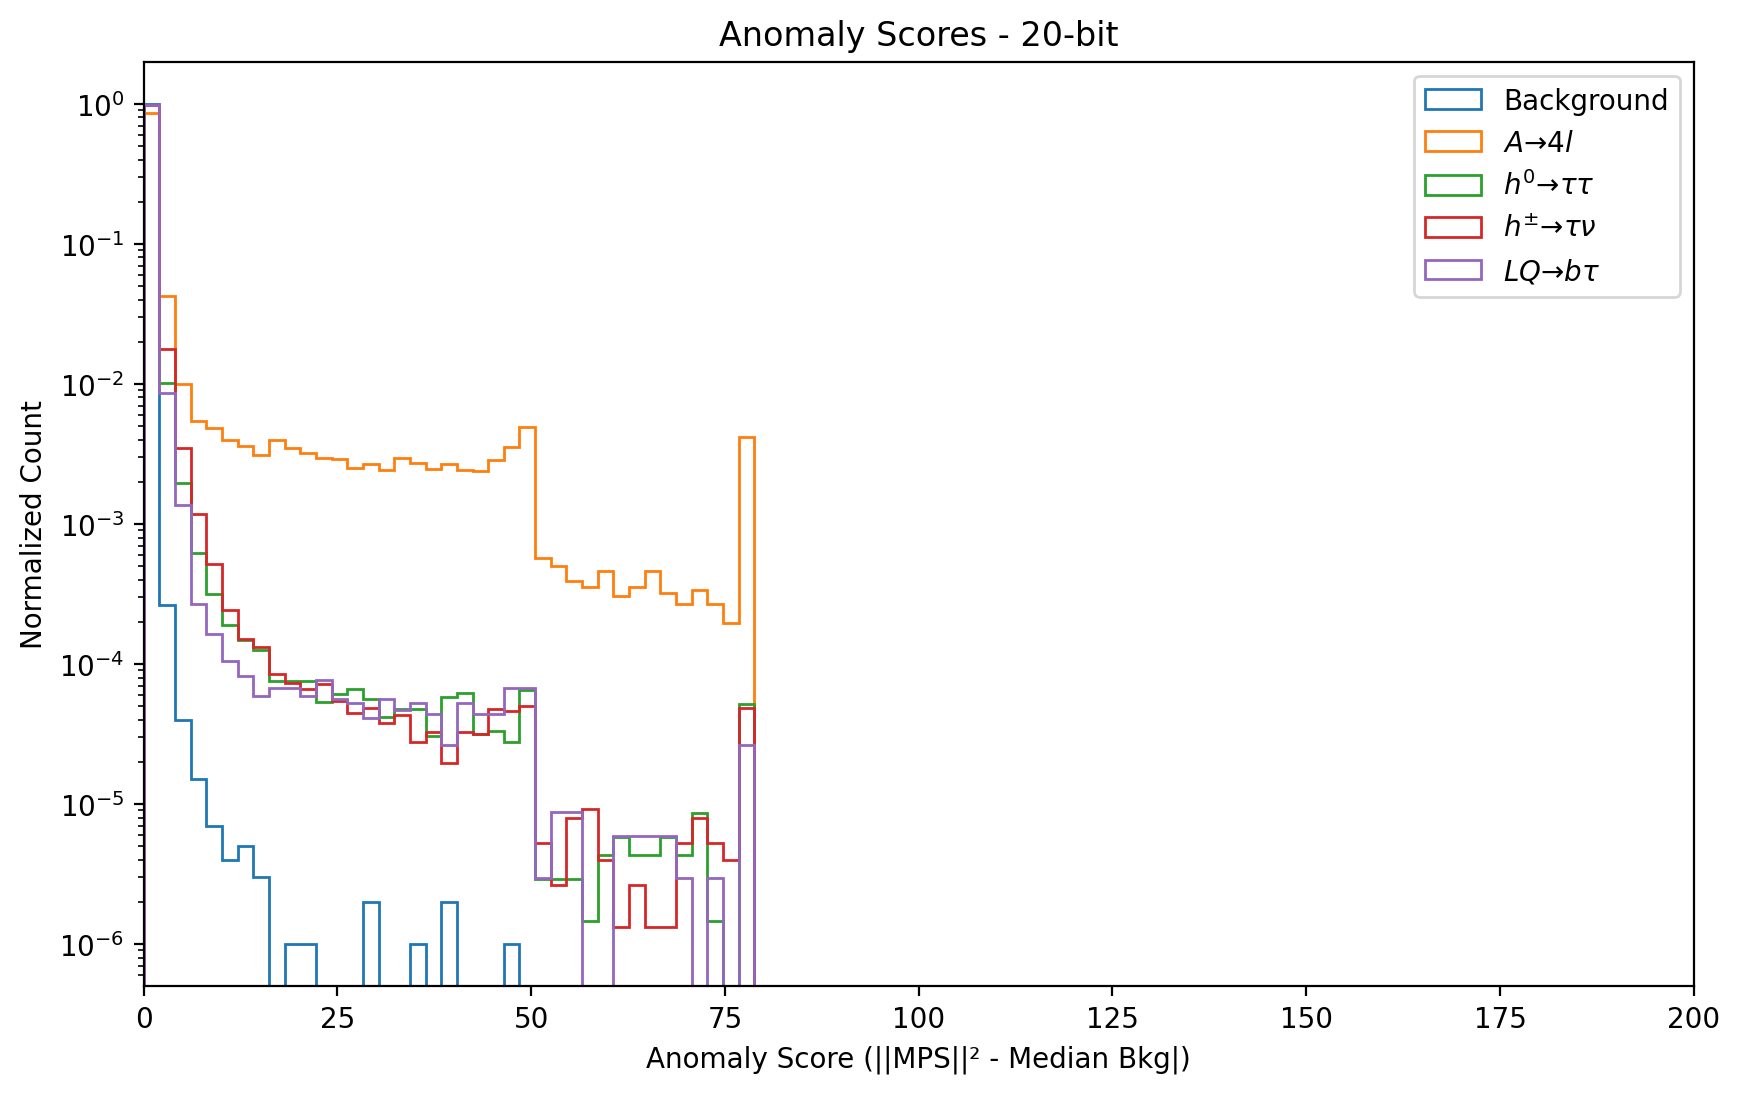

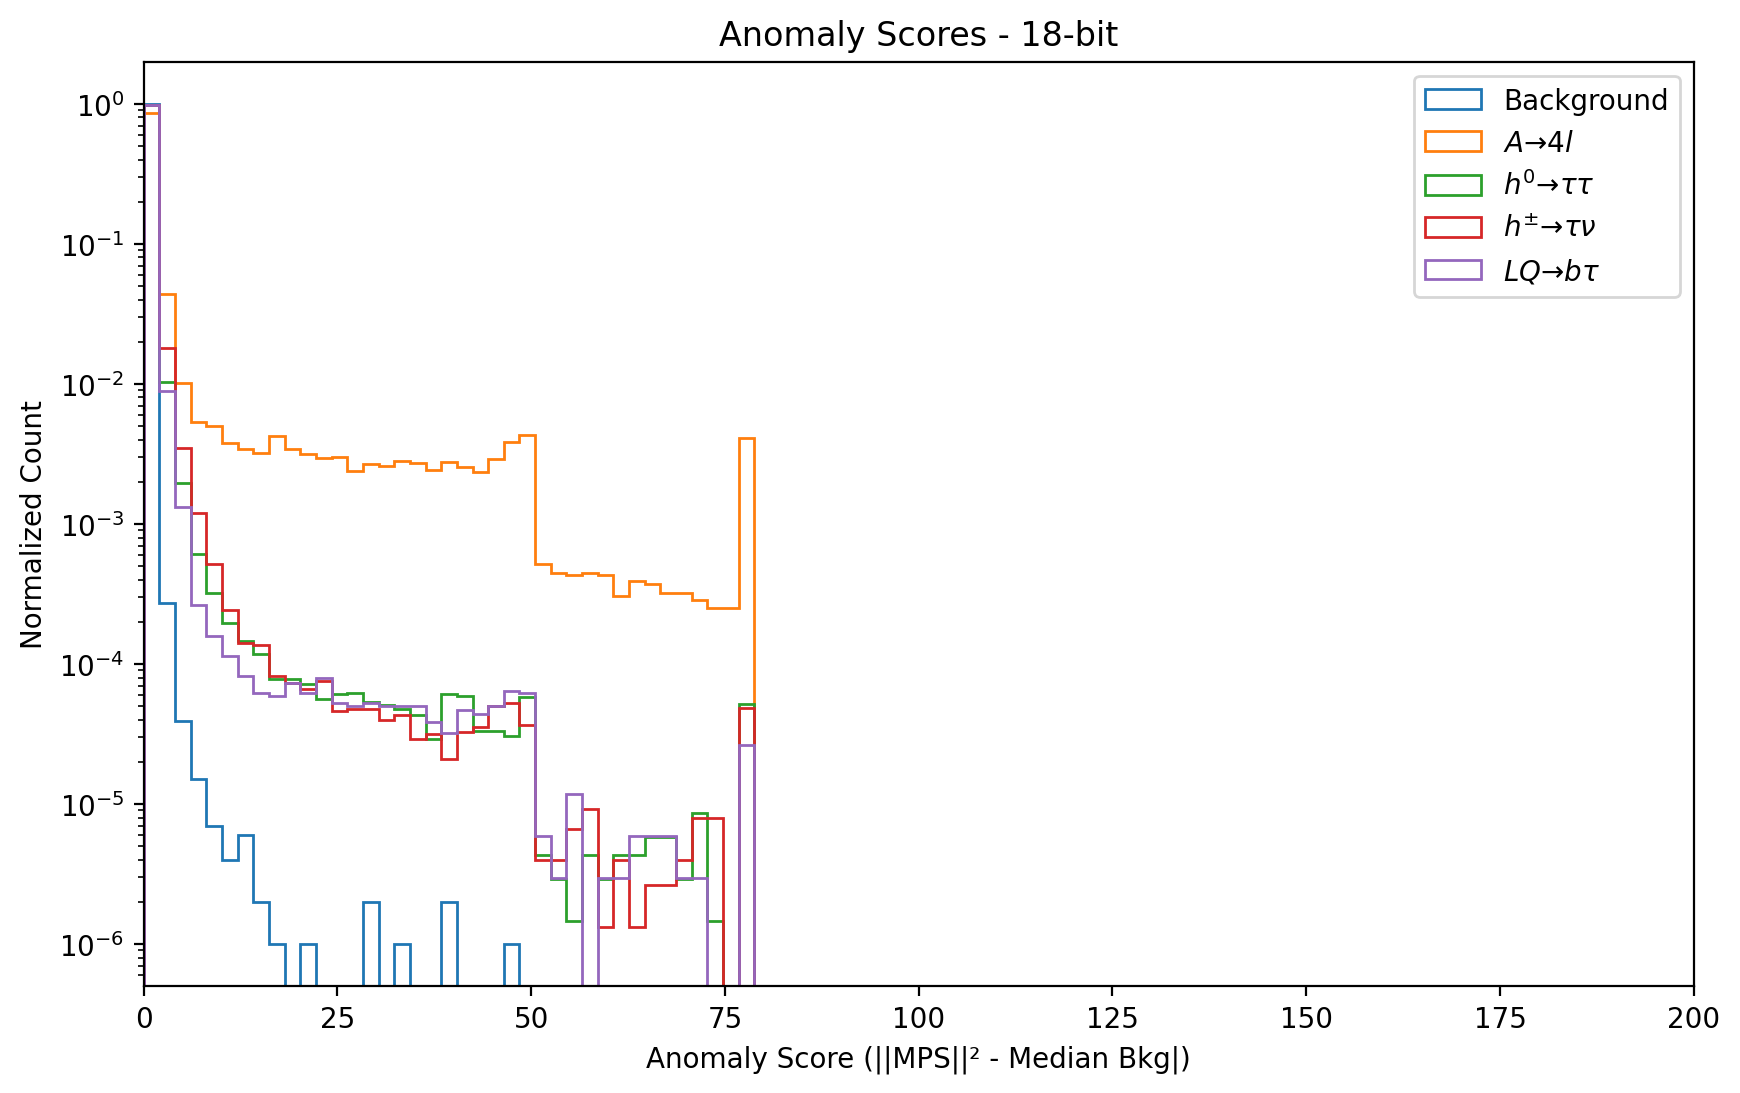

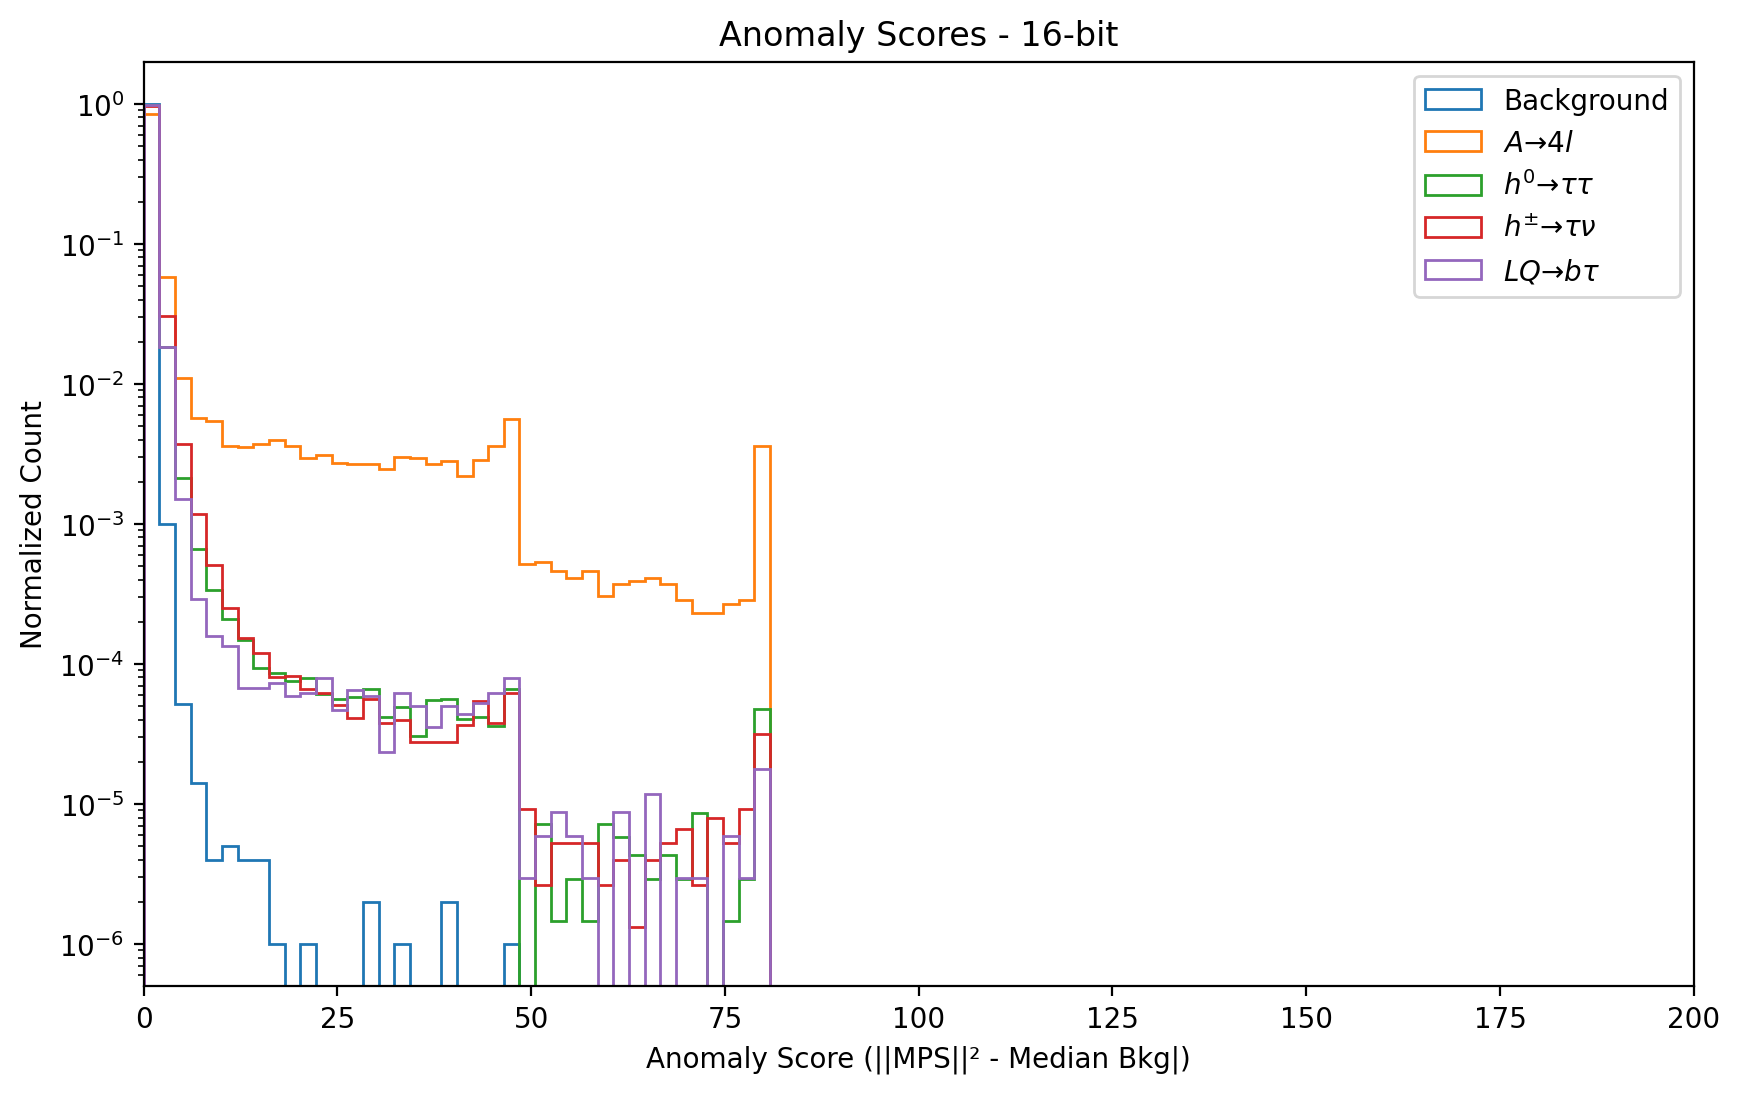

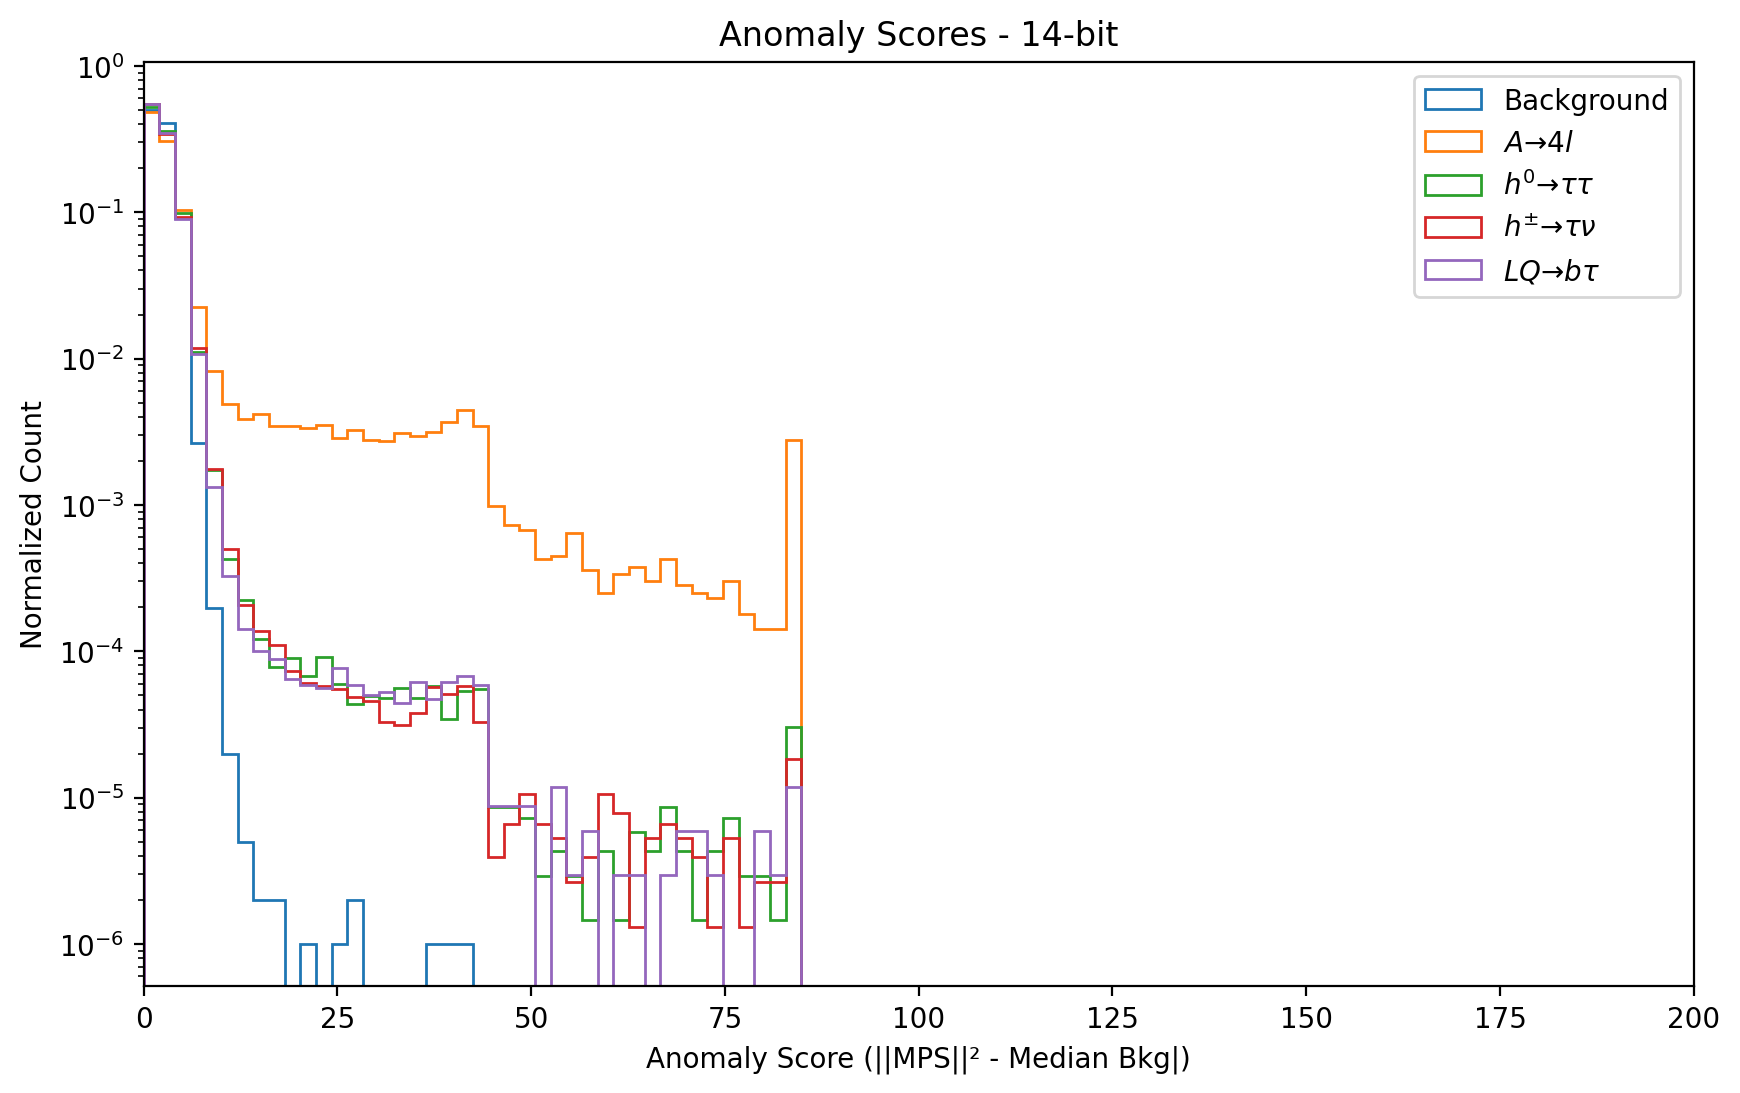

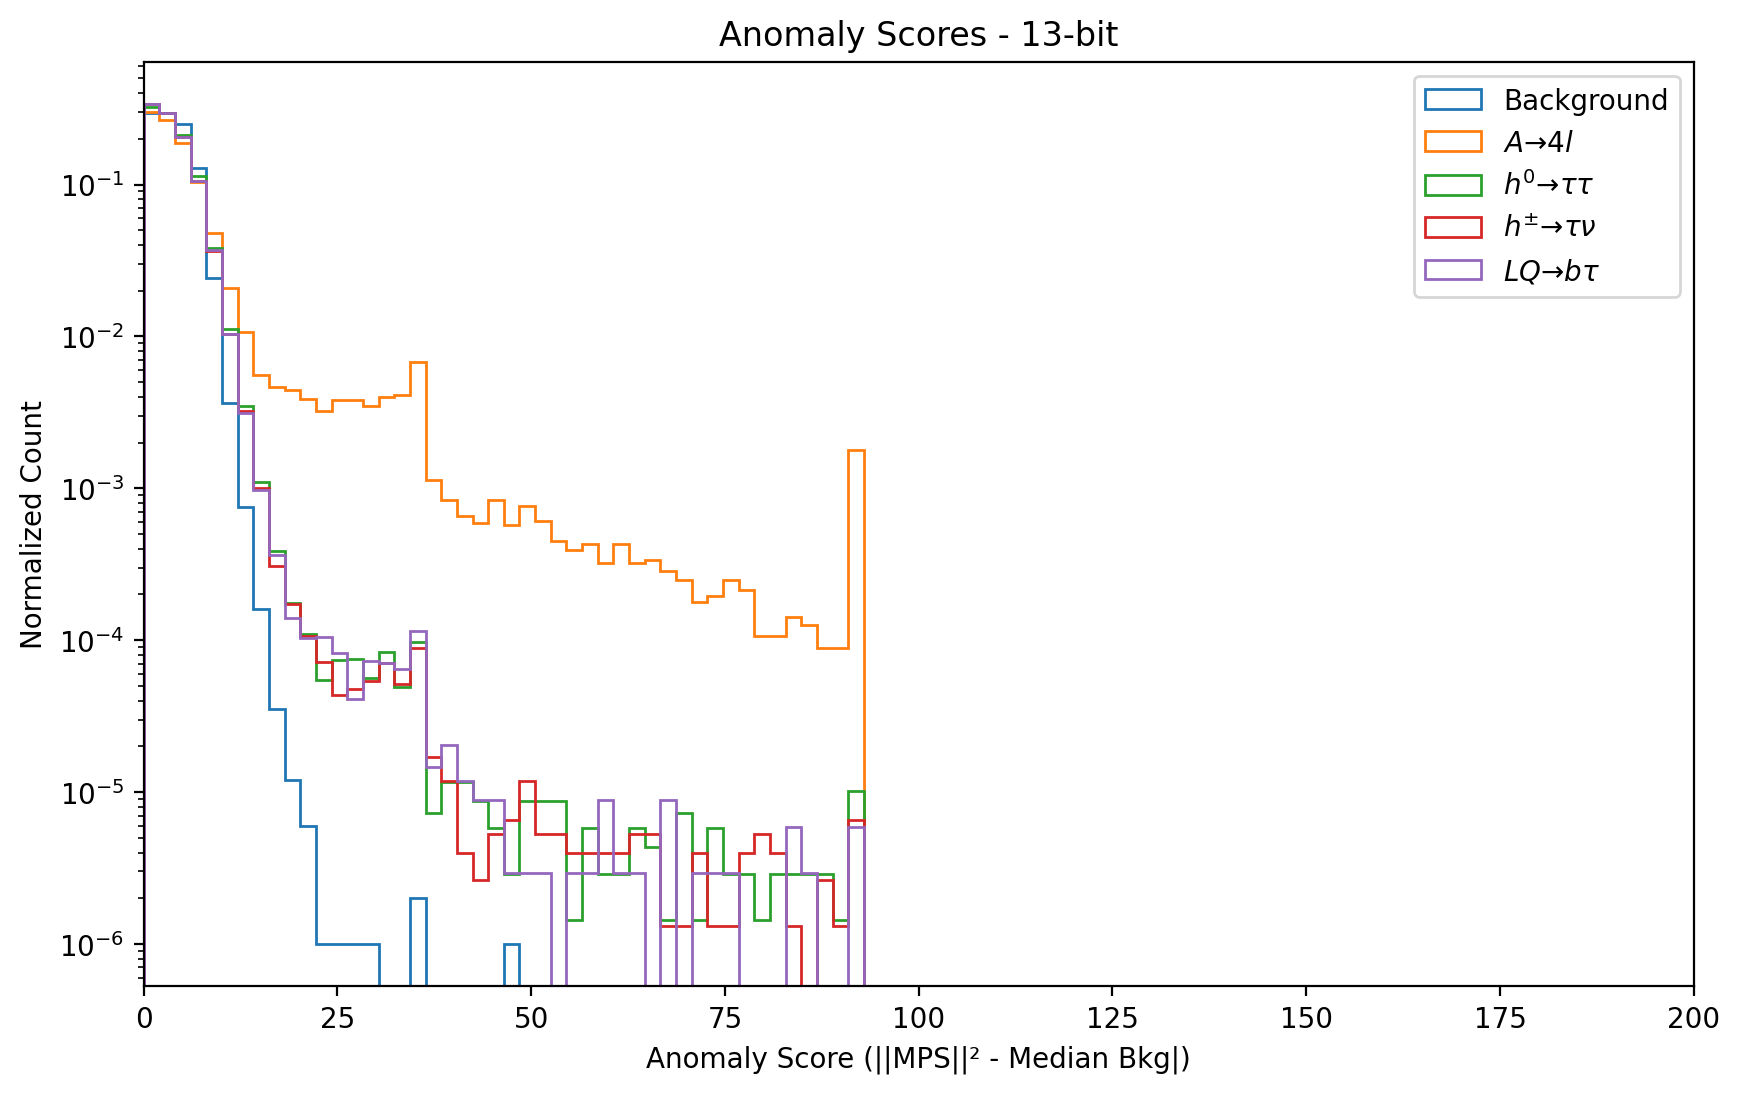

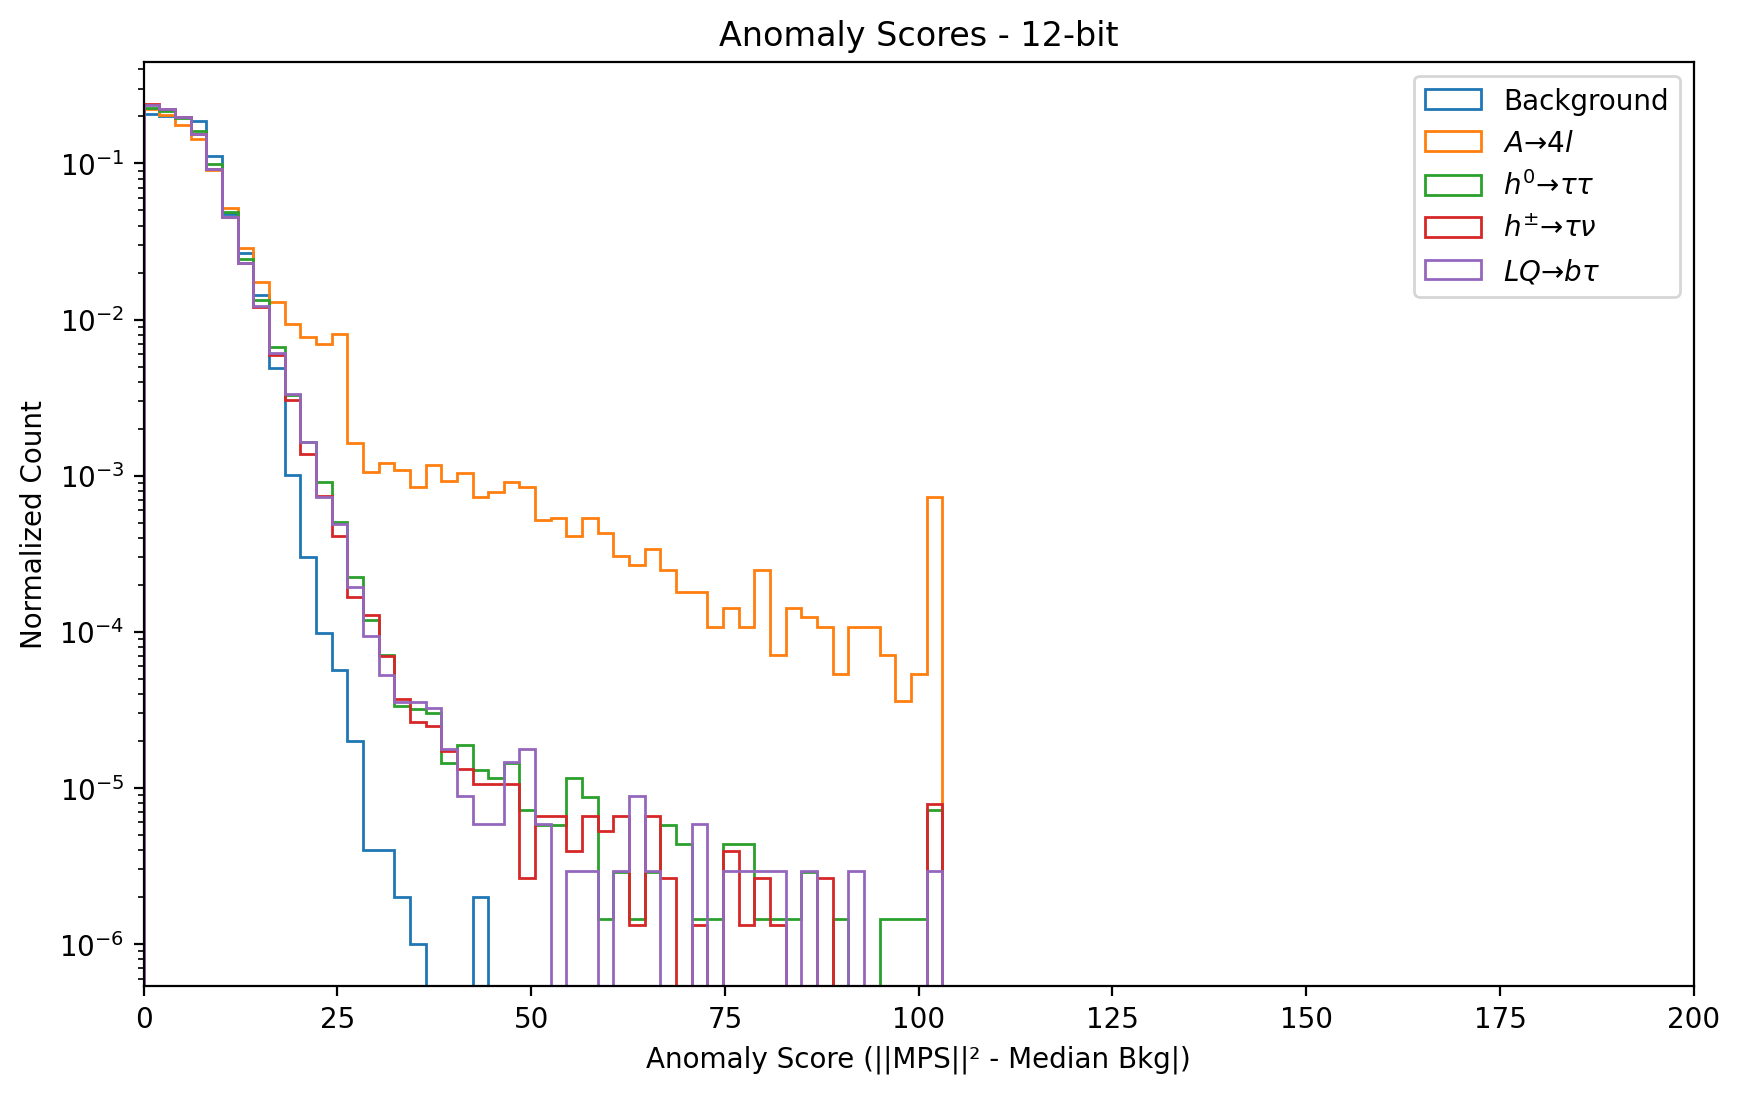

In [14]:
# Plot the anomaly scores (not ROC) in separate panels for each quantization level
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, 100)
for i, quant in enumerate(quantizations):
    plt.figure(figsize=(10, 6), dpi=200)
    for sample in samples:
        plt.hist(anomaly_scores[quant][sample], weights=np.array([1.]*len(anomaly_scores[quant][sample]))/len(anomaly_scores[quant][sample]), bins=bins, histtype='step', color=sample_colors[sample], label=legend_names[sample])  
    plt.xlabel("Anomaly Score (||MPS||\u00b2 - Median Bkg|)")
    plt.yscale("log")
    plt.xlim(0, xmax)
    plt.ylabel("Normalized Count")
    plt.title(f"Anomaly Scores - {legend_names[quant]}")
    plt.legend()
    plt.show()

In [15]:
#copying same roc def as tn4ml eval 
def get_roc_curve_data(y_true: np.ndarray, y_scores: np.ndarray, anomaly_det: bool = False):
    if anomaly_det:
        true_val = np.concatenate((np.ones(y_scores.shape[0]), np.zeros(y_true.shape[0])))
        pred_val = np.concatenate((y_scores, y_true))
    else:
        true_val = y_true
        pred_val = y_scores
    
    fpr, tpr, _ = roc_curve(true_val, pred_val, drop_intermediate=False)

    return fpr, tpr

In [16]:
roc_data = {}
roc_data["tpr"] = {}
roc_data["fpr"] = {}
roc_data["auc"] = {}
roc_data["tpr_at_1e_5_fpr"] = {}
for quant in quantizations:
    roc_data["tpr"][quant] = {}
    roc_data["fpr"][quant] = {}
    roc_data["auc"][quant] = {}
    roc_data["tpr_at_1e_5_fpr"][quant] = {}
    for sample in samples:
       if sample == "bkg":
           continue
       roc_data["fpr"][quant][sample], roc_data["tpr"][quant][sample] = get_roc_curve_data(anomaly_scores[quant]["bkg"], anomaly_scores[quant][sample], anomaly_det=True)
       roc_data["auc"][quant][sample] = auc(roc_data["fpr"][quant][sample], roc_data["tpr"][quant][sample])
       idx_1e_5 = np.searchsorted(roc_data["fpr"][quant][sample], 1e-5, side='right') - 1
       roc_data["tpr_at_1e_5_fpr"][quant][sample] = roc_data["tpr"][quant][sample][idx_1e_5] if idx_1e_5 >= 0 else 0.0

<Figure size 2000x1200 with 0 Axes>

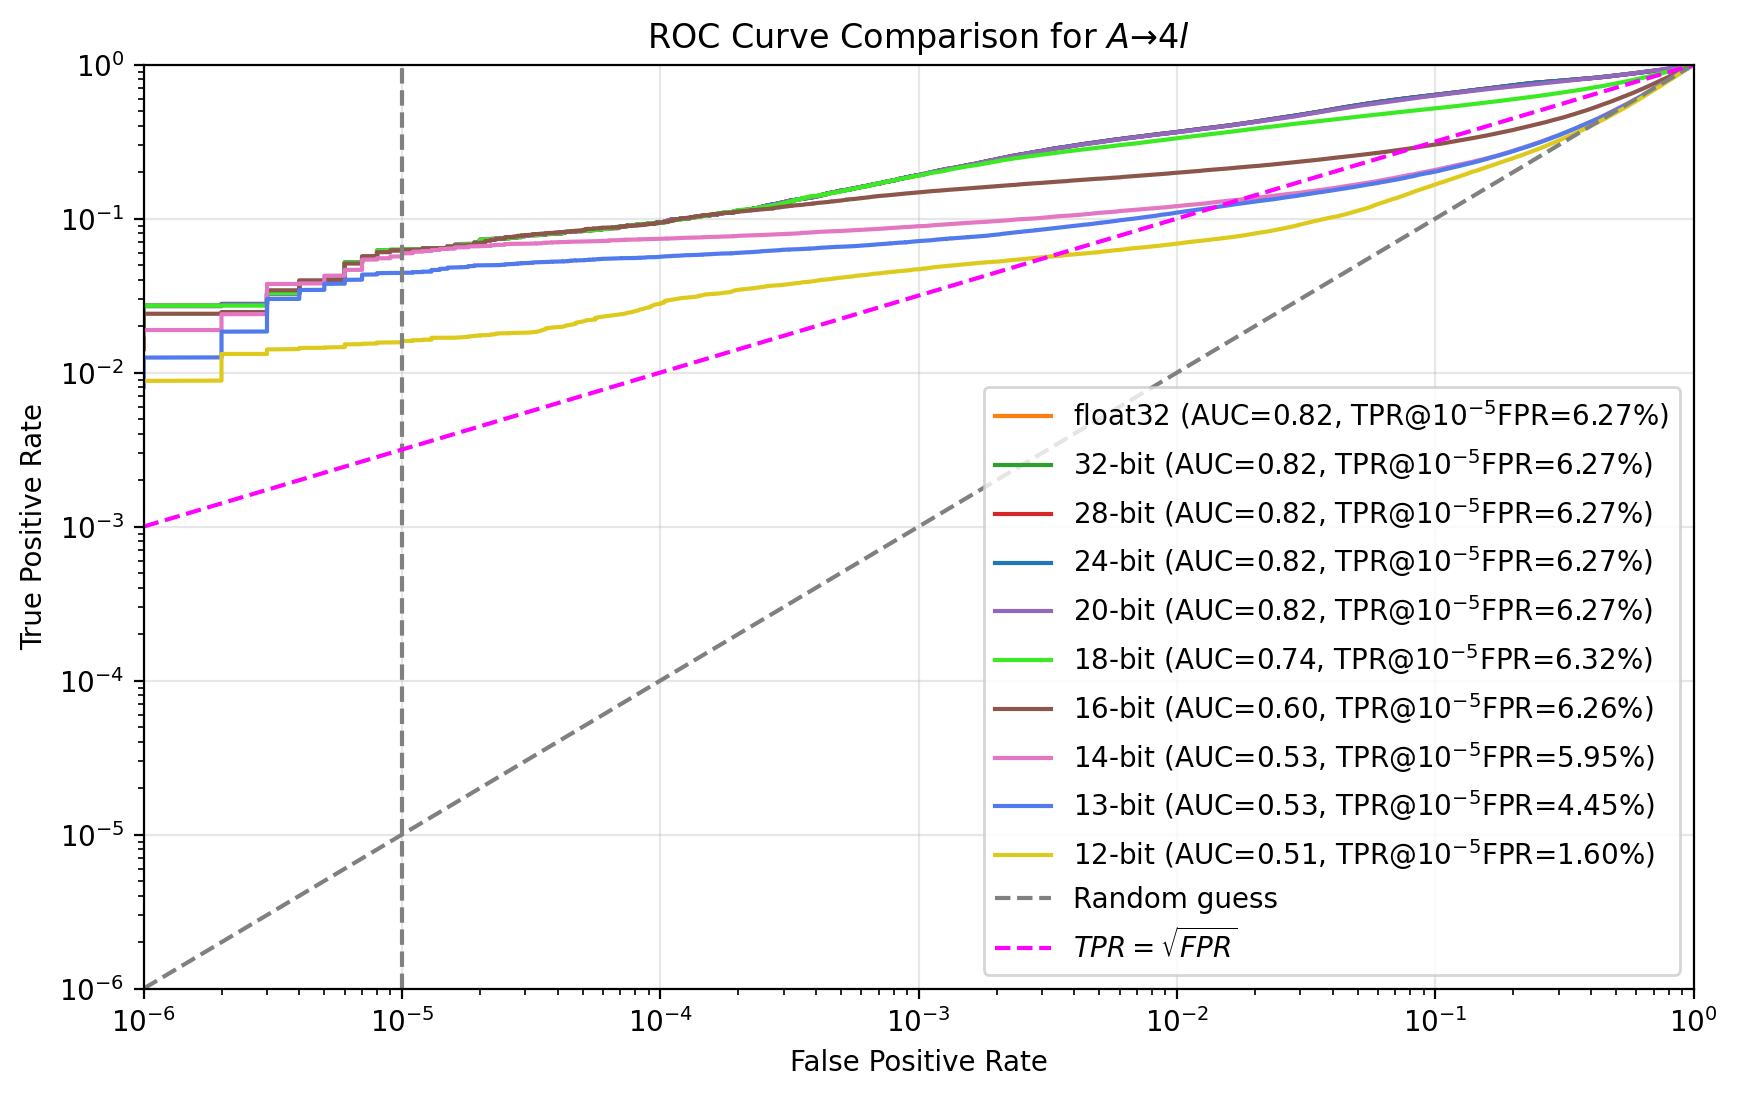

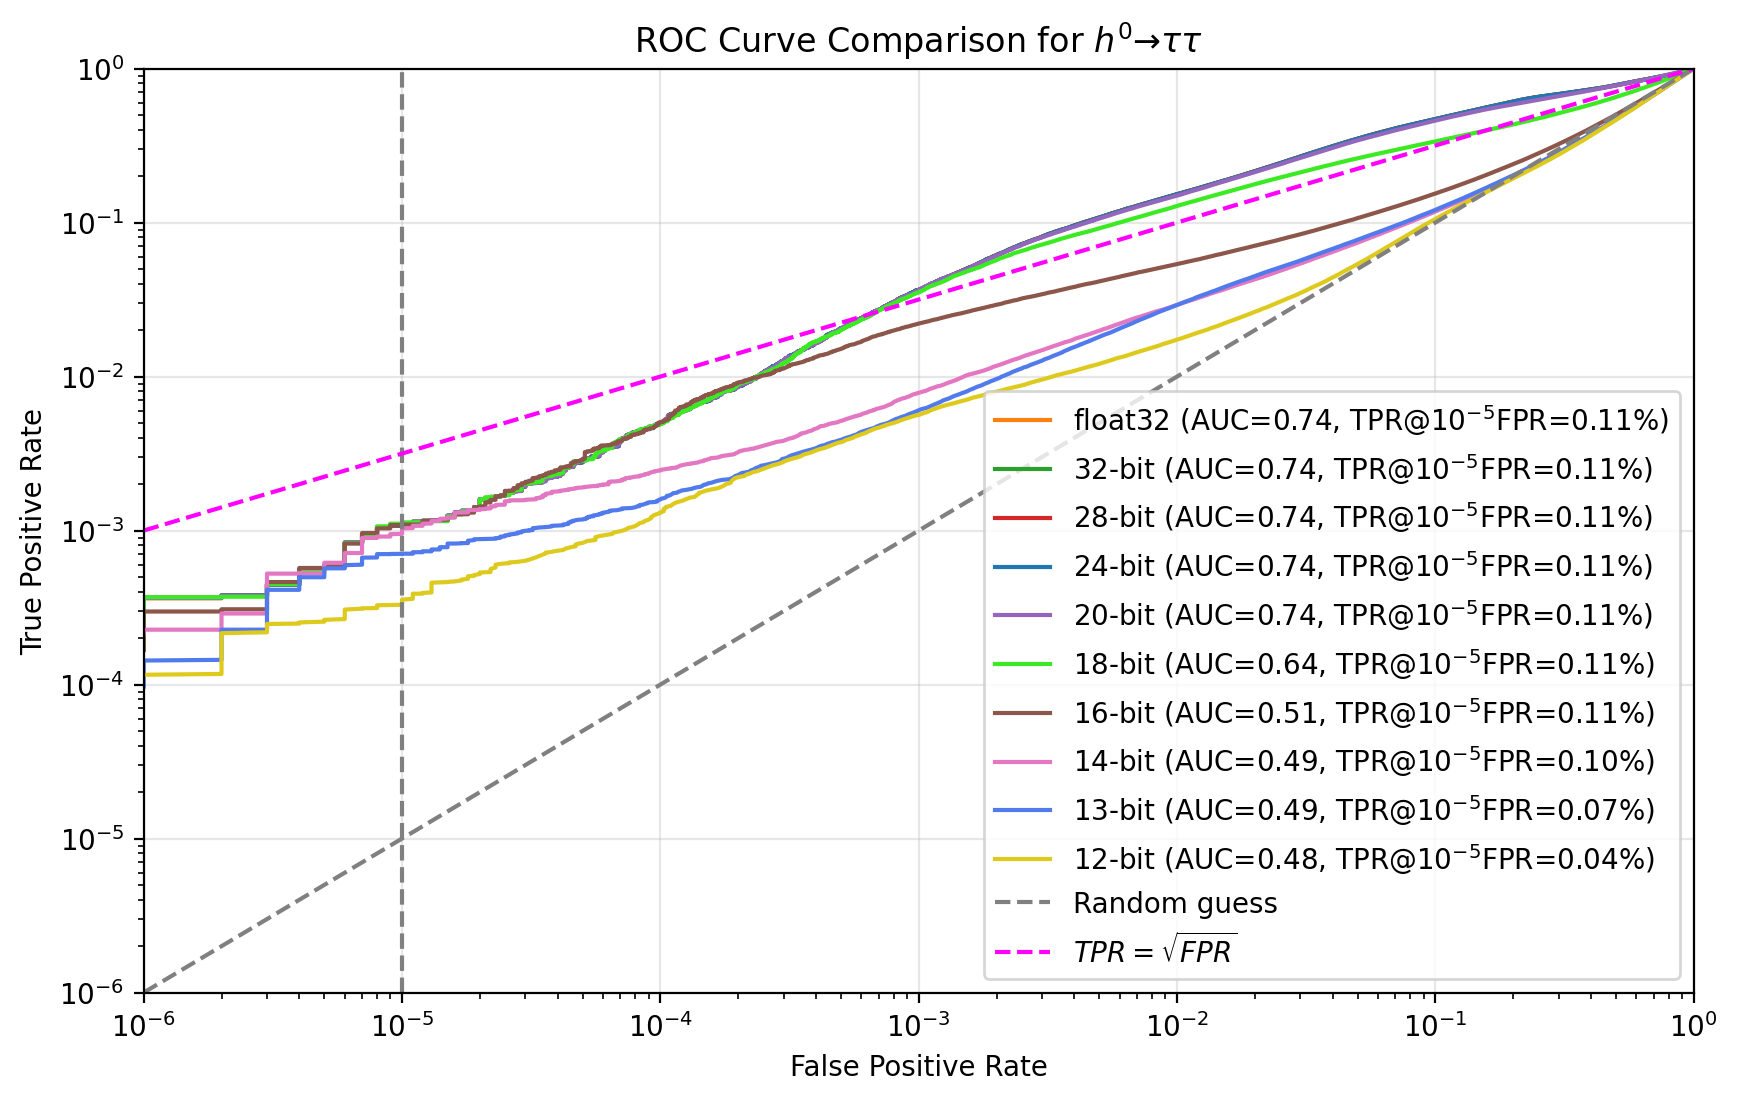

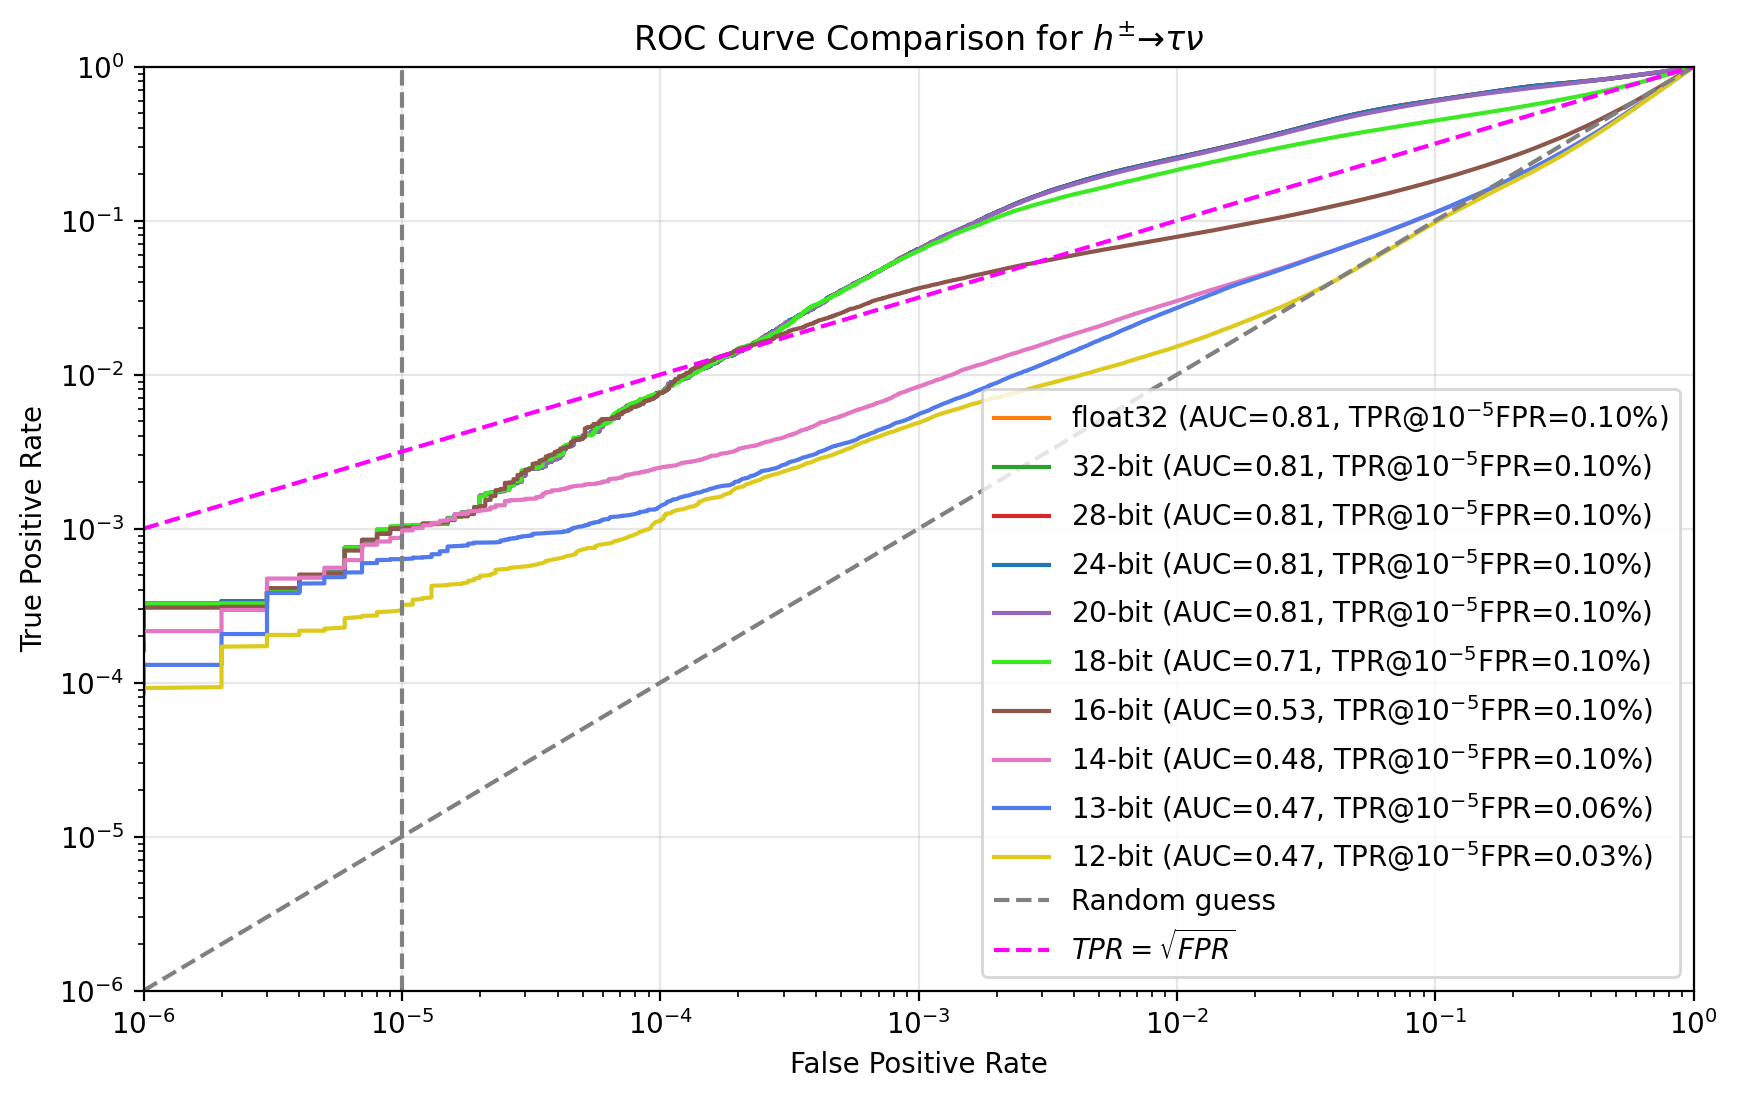

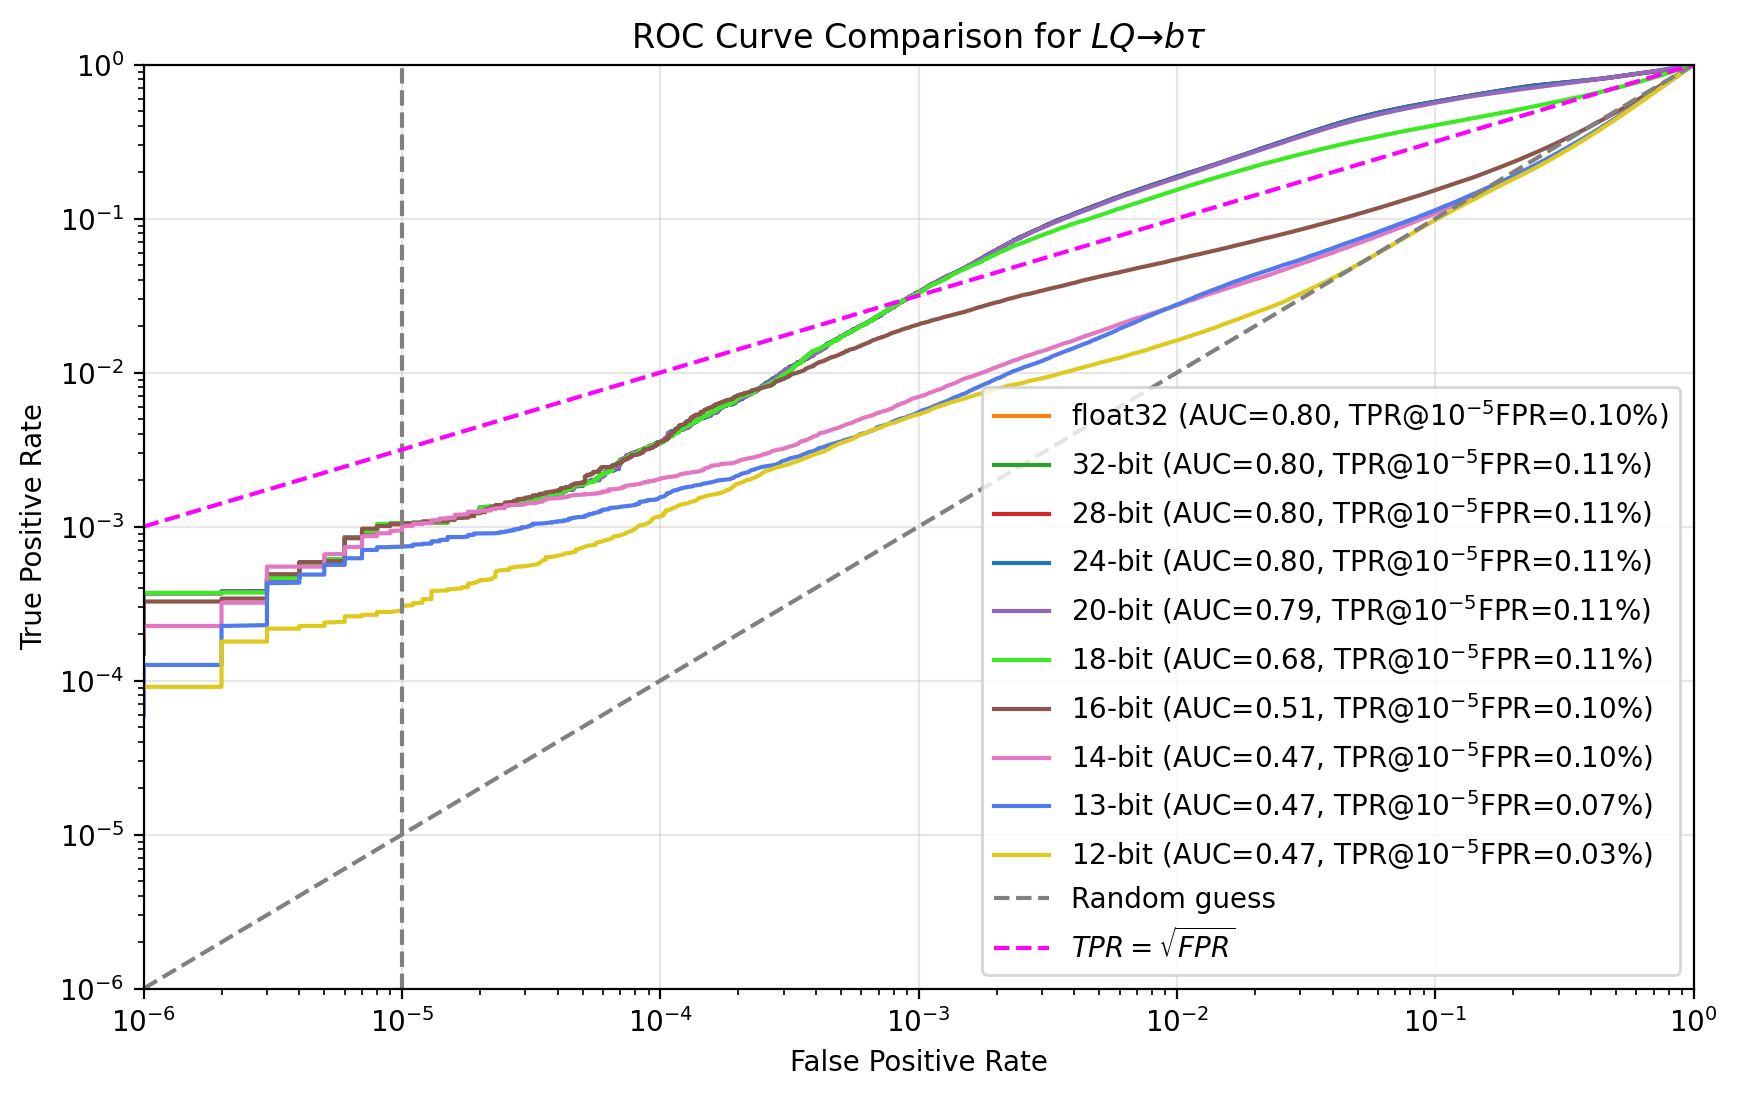

In [ ]:
## Plot ROC curve per sample with different quantizations on the same plot
for sample in samples:
    plt.figure(figsize=(10, 6), dpi=200)
    if sample == "bkg":
        continue
    for quant in quantizations:
        plt.plot(roc_data["fpr"][quant][sample], roc_data["tpr"][quant][sample], color=quantization_colors[quant], label=f"{legend_names[quant]} (AUC={roc_data['auc'][quant][sample]:.2f}, TPR@$10^{'{'}-5{'}'}$FPR={roc_data['tpr_at_1e_5_fpr'][quant][sample]*100:.2f}%)")
    plt.axvline(1e-5, color="gray", linestyle="--")
    plt.plot([1e-6, 1.0], [1e-6, 1.0], linestyle="--", color="gray", label="Random guess")
    # Draw y = sqrt(x) line for reference
    x_ref = np.linspace(1e-6, 1, 100)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Comparison for {legend_names[sample]}")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-6, 1)
    plt.ylim(1e-6, 1)
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")
    plt.show()

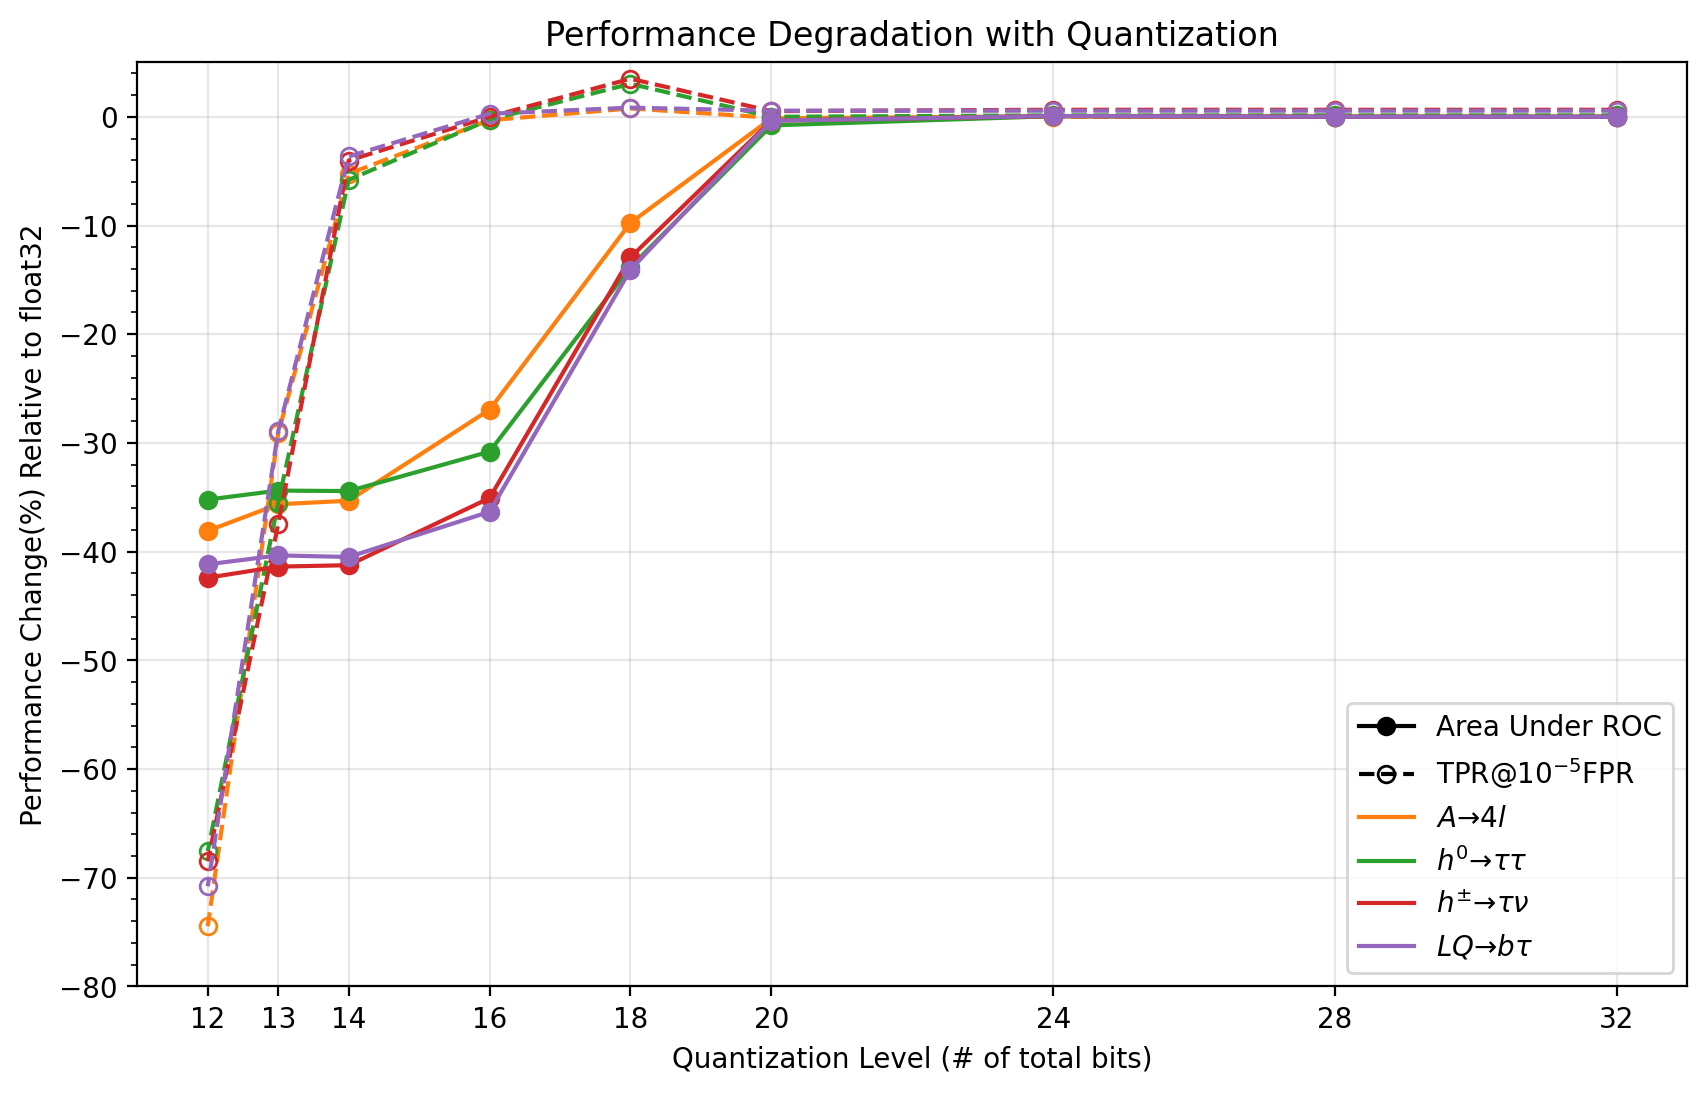

In [18]:
## Plot which shows relative degradation in AUC and TPR@1e-5 FPR compared to float32 with quantization levels on x-axis
plt.figure(figsize=(10, 6), dpi=200)
for sample in samples:
    if sample == "bkg":
        continue
    float_auc = roc_data["auc"]["float32"][sample]
    relative_aucs = [100*(roc_data["auc"][quant][sample]-float_auc)/float_auc for quant in quantizations if quant != "float32"]
    relative_tpr_at_1e_5_fpr = [100*(roc_data["tpr_at_1e_5_fpr"][quant][sample]-roc_data["tpr_at_1e_5_fpr"]["float32"][sample])/roc_data["tpr_at_1e_5_fpr"]["float32"][sample] for quant in quantizations if quant != "float32"]
    plt.plot([int(quant.replace("bit", "")) for quant in quantizations if quant != "float32"], relative_aucs, marker='o', color=sample_colors[sample])
    plt.plot([int(quant.replace("bit", "")) for quant in quantizations if quant != "float32"], relative_tpr_at_1e_5_fpr, marker='o', markerfacecolor='none', linestyle='--', color=sample_colors[sample])
plt.xlabel("Quantization Level (# of total bits)")
plt.ylabel("Performance Change(%) Relative to float32")
plt.title("Performance Degradation with Quantization")
ymin, ymax = -80, 5
plt.ylim(ymin, ymax)
plt.xlim(11, 33)
plt.grid(alpha=0.3)
plt.xticks([12, 13, 14, 16, 18, 20, 24, 28, 32])
plt.yticks(np.arange(ymin, ymax+1, 10))
plt.minorticks_on()
# Remove minor ticks on x-axis
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# Add legend for samples and line styles
handles = []
handles.append(plt.Line2D([0], [0], marker='o', linestyle='-', color='black', label="Area Under ROC"))
handles.append(plt.Line2D([0], [0], marker='o', linestyle='--', markerfacecolor='none', color='black', label=f"TPR@$10^{'{'}-5{'}'}$FPR"))
for sample in samples:
    if sample == "bkg":
        continue
    handles.append(plt.Line2D([0], [0], color=sample_colors[sample], label=legend_names[sample]))
plt.legend(handles=handles, loc="lower right")
# Set high DPI
plt.show()